In [ ]:
!nvidia-smi

Mon Aug 24 21:36:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   41C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

In [ ]:
%pip install -q transformers accelerate bitsandbytes peft
!pip install -q datasets


# ============================================================
#  LOAD DATASET and Analysis
# ============================================================



In [9]:
from datasets import load_dataset
import pandas as pd
import re

ds = load_dataset("FareedKhan/1k_stories_100_genre")
df = ds['train'].to_pandas()

print(df.shape)
print(df['genre'].value_counts())
print(df['genre'].nunique())

README.md:   0%|          | 0.00/1.66k [00:00<?, ?B/s]

1k_stories_100_genre.csv:   0%|          | 0.00/5.92M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

(1000, 4)
genre
Historical Adventure    20
Fantasy                 10
Science Fiction         10
Mystery                 10
Thriller                10
                        ..
Space Exploration       10
Steampunk Fantasy       10
Noir Comedy             10
Social Commentary       10
Techno-Mystery          10
Name: count, Length: 99, dtype: int64
99


In [ ]:
# Check for hidden duplicates (whitespace, case differences)
raw_genres = df['genre'].tolist()
print("Raw unique count:", len(set(raw_genres)))

cleaned_genres = df['genre'].str.strip().str.lower()
print("Cleaned unique count:", cleaned_genres.nunique())

# Show the actual sorted list so you can eyeball it
print(sorted(df['genre'].unique()))

Raw unique count: 99
Cleaned unique count: 99
['Adventure', 'Alternate Dimension', 'Alternate History', 'Alternate Reality', 'Animal Fantasy', 'Animal Fiction', 'Anthology', 'Apocalyptic', 'Apocalyptic Comedy', 'Artificial Intelligence', 'Artistic Drama', 'Biographical', 'Comedy', 'Coming-of-Age', 'Coming-of-Middle-Age', 'Crime', 'Cyberpunk', 'Detective Fiction', 'Disaster', 'Domestic Fiction', 'Dreamlike', 'Dystopian', 'Environmental', 'Espionage', 'Evolutionary Fiction', 'Existential Drama', 'Experimental', 'Fairy Tale', 'Family Drama', 'Fantasy', 'Folklore', 'Futuristic', 'Generation Gap', 'Gothic', 'Hard Science Fiction', 'Historical Adventure', 'Historical Fiction', 'Historical Romance', 'Horror', 'Humor', 'Inspirational', 'Legal Drama', 'Magical Girl', 'Magical Realism', 'Medical Drama', 'Medical Mystery', 'Military Fiction', 'Multiverse', 'Mystery', 'Mystery Comedy', 'Mystery Thriller', 'Mythic Fiction', 'Mythology', 'Nautical Fiction', 'Noir', 'Noir Comedy', 'Paranormal', 'Phil

In [ ]:
from huggingface_hub import hf_hub_download
import pickle

pkl_path = hf_hub_download(repo_id="FareedKhan/1k_stories_100_genre", filename="story_genres.pkl", repo_type="dataset")

with open(pkl_path, 'rb') as f:
    story_genres = pickle.load(f)

print(len(story_genres))
print(set(story_genres) - set(df['genre'].unique()))  # genres declared but never used
print(set(df['genre'].unique()) - set(story_genres))  # genres used but not declared

story_genres.pkl: reconstructing file:   0%|          |  0.00B / 1.61kB            

story_genres.pkl: downloading bytes:           |  0.00B            

100
set()
set()


In [ ]:
print(len(story_genres))
print(len(set(story_genres)))  # unique count in the pkl itself

100
99


In [ ]:
from collections import Counter

counts = Counter(story_genres)
duplicates = {genre: count for genre, count in counts.items() if count > 1}
print(duplicates)

{'Historical Adventure': 2}


##Loading Tokenizer to decide chuncking strategy


In [ ]:
!pip install -q transformers

from transformers import AutoTokenizer

# using a common tokenizer as a rough proxy for now
tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")

df['story_tokens'] = df['story'].apply(lambda x: len(tok.encode(x)))
print(df['story_tokens'].describe())
print(df['story_tokens'].max())

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

count    1000.000000
mean     1208.195000
std       516.230463
min        95.000000
25%       993.000000
50%      1202.000000
75%      1428.000000
max      3677.000000
Name: story_tokens, dtype: float64
3677


# ============================================================
# BUILD EMBEDDINGS (semantic representation of stories)
# ============================================================


In [ ]:
!pip install -q sentence-transformers faiss-cpu

from sentence_transformers import SentenceTransformer
import numpy as np

embed_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 126.3 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Combine title + story for richer semantic representation
df['text_for_embedding'] = df['title'] + ". " + df['story']

embeddings = embed_model.encode(
    df['text_for_embedding'].tolist(),
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(embeddings.shape)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

(1000, 384)


##Tracking for GPU Usage


In [5]:
import torch

def report_vram(label=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        peak = torch.cuda.max_memory_allocated() / 1024**3
        print(f"[{label}] Allocated: {allocated:.2f} GB | Reserved: {reserved:.2f} GB | Peak: {peak:.2f} GB")
    else:
        print("No GPU available")



# ============================================================
# BUILD FAISS INDEX + EXACT-MATCH LOOKUP STRUCTURES
# ============================================================



In [ ]:
import faiss

# Normalize embeddings for cosine similarity via inner product
faiss.normalize_L2(embeddings)

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # Inner Product = cosine similarity since normalized
index.add(embeddings)

print(f"FAISS index built with {index.ntotal} vectors")

# Exact-match lookup structures for non-semantic queries
id_to_row = {row['id']: i for i, row in df.iterrows()}
title_to_row = {row['title'].lower(): i for i, row in df.iterrows()}
genre_to_rows = df.groupby('genre').apply(lambda x: x.index.tolist()).to_dict()

print(f"ID lookup entries: {len(id_to_row)}")
print(f"Title lookup entries: {len(title_to_row)}")
print(f"Genre buckets: {len(genre_to_rows)}")

FAISS index built with 1000 vectors
ID lookup entries: 1000
Title lookup entries: 998
Genre buckets: 99


/tmp/ipykernel_12413/3861269992.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_to_rows = df.groupby('genre').apply(lambda x: x.index.tolist()).to_dict()


In [ ]:
# --- Data Quality Check: Title Uniqueness ---
# Earlier inspection showed title_to_row (dict keyed by title) had fewer entries
# than total rows (998 vs 1000), meaning some titles collide when lowercased.
# Before deciding how to handle this in the retrieval layer, we first need to know
# whether these are genuine duplicate titles or the same story listed twice.
dupe_titles = df[df['title'].str.lower().duplicated(keep=False)]
print(dupe_titles[['id', 'title', 'genre']])

         id                               title                 genre
62   735471       The Voyage of The Sea Serpent      Nautical Fiction
403  320505  The Chronicles of the Lost Kingdom  Historical Adventure
703  632633  The Chronicles of The Lost Kingdom  Historical Adventure
762  623181       The Voyage of the Sea Serpent      Nautical Fiction


In [ ]:
# --- Data Quality Check: Confirm Collisions Are Distinct Stories, Not Duplicates ---
# Two title collisions were found above. Before deciding whether to deduplicate
# the dataset or handle both as separate valid stories, we compare the actual
# story text for each pair to rule out the possibility that they're identical
# content under two different IDs (a genuine data error vs. a coincidental title match).
pairs = [(62, 762), (403, 703)]  # row indices from your output above

for i, j in pairs:
    story_i = df.loc[i, 'story']
    story_j = df.loc[j, 'story']
    print(f"Pair ({df.loc[i,'id']}, {df.loc[j,'id']}):")
    print(f"  Identical text: {story_i == story_j}")
    print(f"  Length i: {len(story_i)}, Length j: {len(story_j)}")
    print(f"  First 150 chars i: {story_i[:150]}")
    print(f"  First 150 chars j: {story_j[:150]}")
    print()

Pair (735471, 623181):
  Identical text: False
  Length i: 6645, Length j: 6245
  First 150 chars i: Once upon a time, in the quaint little coastal village of Port Haven, there lived a group of sailors who were known far and wide for their extraordina
  First 150 chars j: In the small coastal town of Newport, Rhode Island, lived a young and ambitious man named Thomas Carrington. Thomas was a skilled shipwright, well-kno

Pair (320505, 632633):
  Identical text: False
  Length i: 7631, Length j: 6091
  First 150 chars i: In the year 1465, during the reign of King Edward IV of England, a mysterious kingdom known as Eldoria lay hidden in the heart of an ancient and dense
  First 150 chars j: In the year 1576, in the land of Eldoria, a kingdom lay forgotten, lost in the sands of time. This was the tale of a brave group of adventurers, bound



In [ ]:
# --- Build Title Lookup (collision-safe) ---
# Confirmed above that title collisions are between genuinely different stories,
# not duplicate data. A dict keyed by title -> single row index would silently
# drop one story per collision. Instead, we map each title to a LIST of row
# indices, so retrieval can return and answer for every story matching a given
# title rather than losing one to an overwrite.
from collections import defaultdict

title_to_rows = defaultdict(list)
for i, row in df.iterrows():
    title_to_rows[row['title'].lower()].append(i)

title_to_rows = dict(title_to_rows)

print(f"Unique titles: {len(title_to_rows)}")
print(f"Titles with multiple matches: {[(t, rows) for t, rows in title_to_rows.items() if len(rows) > 1]}")

Unique titles: 998
Titles with multiple matches: [('the voyage of the sea serpent', [62, 762]), ('the chronicles of the lost kingdom', [403, 703])]


In [ ]:
# --- Build Genre Lookup ---
# Maps each genre string to the list of row indices belonging to it, enabling
# O(1) exact lookup for genre-based queries (e.g. "stories in the Horror genre")
# without needing a semantic search. include_groups=False silences a pandas
# deprecation warning with no change in behavior.
genre_to_rows = df.groupby('genre', group_keys=False)[['id']].apply(lambda x: x.index.tolist(), include_groups=False).to_dict()

# ============================================================
#  CONTEXT & PROMPT CONSTRUCTION
# ============================================================

In [ ]:
def build_context(results, method, max_full_stories=3):
    if method == "genre_lookup" and len(results) > max_full_stories:
        context_parts = []
        for r in results:
            excerpt = r['story'][:200].rsplit(' ', 1)[0] + "..."
            context_parts.append(f"Title: {r['title']}\nExcerpt: {excerpt}")
        return "\n\n".join(context_parts), "summarized"
    else:
        context_parts = []
        for idx, r in enumerate(results, 1):
            label = f"STORY {idx} of {len(results)} (ID: {r['id']})" if len(results) > 1 else "STORY"
            context_parts.append(f"{label}\nTitle: {r['title']}\nGenre: {r['genre']}\nFull Story: {r['story']}")
        return "\n\n".join(context_parts), "full_text"


def has_direct_dialogue(story_text):
    """
    Heuristic check: does the story contain actual quoted speech?
    Checks both straight and curly quote styles.
    """
    return bool(re.search(r'["\u201C].{5,}?["\u201D]', story_text))

def build_prompt(query, context, context_type, dialogue_fact=None):
    if context_type == "summarized":
        instruction = (
            "You are given titles and short excerpts from multiple stories. "
            "Answer the user's question by referring only to the information given below. "
            "If asked for a full summary of a specific story, tell the user you can look it up "
            "by title or ID for more detail."
        )
    else:
        instruction = (
            "You are given the full text of one or more stories, each clearly labeled and numbered. "
            "If there is more than one story, you MUST address each one separately and distinctly in your answer — "
            "do not merge them or only describe one. "
            "Answer the user's question accurately based only on the story content below. "
            "Do not invent details not present in the text."
        )

    dialogue_note = ""
    if dialogue_fact is False:
        dialogue_note = (
            "\n\nVERIFIED FACT: This story contains NO direct quoted dialogue anywhere in the text. "
            "All speech and conversation is conveyed narratively. "
            "If the user asks about dialogue or conversations, state this fact clearly and describe "
            "the relevant interactions in your own words. "
            "Do NOT use quotation marks anywhere in your answer, for any reason — not to quote, "
            "not to paraphrase, not as an example. Quotation marks imply direct speech that does not exist here."
        )

    return f"""{instruction}{dialogue_note}

STORY CONTEXT:
{context}

USER QUESTION: {query}

ANSWER:"""





# ============================================================
#  LOAD LLM (Qwen2.5-7B-Instruct, 4-bit quantized)
# ============================================================

In [6]:
!pip install -q transformers accelerate bitsandbytes

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

report_vram("before loading LLM")

model_name = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

llm_tokenizer = AutoTokenizer.from_pretrained(model_name)
llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

report_vram("after loading LLM (4-bit)")

[before loading LLM] Allocated: 0.00 GB | Reserved: 0.00 GB | Peak: 0.00 GB


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

[after loading LLM (4-bit)] Allocated: 5.18 GB | Reserved: 5.33 GB | Peak: 5.30 GB


# ============================================================
#  CHATBOT WRAPPER CLASS (StoryChatbot)
# ============================================================

In [ ]:
import re
class StoryChatbot:
    """
    Task 1: Story Retrieval Chatbot
    Wraps routing, context construction, and generation into a single interface.
    """

    def __init__(self, df, index, embed_model, llm_model, llm_tokenizer,
                 id_to_row, title_to_rows, genre_to_rows):
        self.df = df
        self.index = index
        self.embed_model = embed_model
        self.llm_model = llm_model
        self.llm_tokenizer = llm_tokenizer
        self.id_to_row = id_to_row
        self.title_to_rows = title_to_rows
        self.genre_to_rows = genre_to_rows

    def _route_query(self, query, top_k=3):
        query_lower = query.lower().strip()

        # 1. ID lookup — if a number looks like an ID attempt but isn't found, say so explicitly
        id_match = re.search(r'\bid\s*:?\s*(\d+)\b', query_lower) or re.search(r'\b(\d{3,10})\b', query)
        if id_match:
            story_id = int(id_match.group(1))
            if story_id in id_to_row:
                row = df.loc[id_to_row[story_id]]
                return [row.to_dict()], "id_lookup"
            else:
                return [], "id_not_found"

        # TITLE LOOKUP — moved BEFORE genre patterns (this is the fix)
        title_phrase_match = re.search(r'(?:titled?|called)\s+["\']?(.+?)["\']?\??$', query_lower)
        for title, indices in self.title_to_rows.items():
            if title in query_lower:
                rows = self.df.loc[indices]
                return rows.to_dict('records'), "title_lookup"
        if title_phrase_match:
            return [], "title_not_found"

        # Genre lookup — unchanged, now only reached if no title matched
        genre_trigger_patterns = [
            r'\bin the (.+?) genre\b',
            r'\bstories? (?:in|of|from) (.+?)(?:\s+genre)?$',
            r'\bgenre[:\s]+(.+)$',
        ]
        for pattern in genre_trigger_patterns:
            match = re.search(pattern, query_lower)
            if match:
                candidate = match.group(1).strip()
                matched_genre = None
                for genre in self.genre_to_rows.keys():
                    if genre.lower() == candidate or genre.lower() in candidate:
                        matched_genre = genre
                        break
                if matched_genre:
                    rows = self.df.loc[self.genre_to_rows[matched_genre]]
                    return rows.to_dict('records'), "genre_lookup"
                else:
                    return [], "genre_not_found"

        # 4. Fallback: semantic search
        query_embedding = embed_model.encode([query], convert_to_numpy=True)
        faiss.normalize_L2(query_embedding)
        scores, indices = index.search(query_embedding, top_k)
        rows = df.iloc[indices[0]]
        return rows.to_dict('records'), "semantic_search"

    def _build_context(self, results, method, max_full_stories=3):
        if method == "genre_lookup" and len(results) > max_full_stories:
            context_parts = []
            for r in results:
                excerpt = r['story'][:200].rsplit(' ', 1)[0] + "..."
                context_parts.append(f"Title: {r['title']}\nExcerpt: {excerpt}")
            return "\n\n".join(context_parts), "summarized"
        else:
            context_parts = []
            for idx, r in enumerate(results, 1):
                label = f"STORY {idx} of {len(results)} (ID: {r['id']})" if len(results) > 1 else "STORY"
                context_parts.append(f"{label}\nTitle: {r['title']}\nGenre: {r['genre']}\nFull Story: {r['story']}")
            return "\n\n".join(context_parts), "full_text"

    def _build_prompt(self, query, context, context_type, dialogue_fact=None):
        return build_prompt(query, context, context_type, dialogue_fact)  # reuse function above


    def _generate(self, prompt, max_new_tokens=600):
        messages = [{"role": "user", "content": prompt}]
        text = self.llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = self.llm_tokenizer(text, return_tensors="pt").to(self.llm_model.device)
        with torch.no_grad():
            outputs = self.llm_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=0.7,
                do_sample=True,
                pad_token_id=self.llm_tokenizer.eos_token_id,
            )
        generated = outputs[0][inputs['input_ids'].shape[1]:]
        return self.llm_tokenizer.decode(generated, skip_special_tokens=True)

    def ask(self, query, top_k=3, verbose=False):
        results, method = self._route_query(query, top_k=top_k)

        if method in ("id_not_found", "genre_not_found", "title_not_found"):
            kind = method.replace("_not_found", "")
            return f"I couldn't find a story matching that {kind}. Could you double-check it or try a different search?"

        # Compute dialogue_fact once for the retrieved story text(s)
        combined_text = " ".join(r['story'] for r in results) if results else ""
        dialogue_fact = has_direct_dialogue(combined_text) if combined_text else None

        if method == "title_lookup" and len(results) > 1:
            answers = []
            for r in results:
                fact = has_direct_dialogue(r['story'])
                single_prompt = self._build_prompt(
                    query,
                    f"Title: {r['title']}\nGenre: {r['genre']}\nFull Story: {r['story']}",
                    "full_text",
                    dialogue_fact=fact
                )
                answers.append(f"[Story ID {r['id']} - {r['genre']}]\n{self._generate(single_prompt)}")
            return f"Note: {len(results)} different stories share this title. Here is each one:\n\n" + "\n\n---\n\n".join(answers)

        context, ctype = self._build_context(results, method)
        prompt = self._build_prompt(query, context, ctype, dialogue_fact=dialogue_fact)
        answer = self._generate(prompt)

        if verbose:
            print(f"[method={method}, context_type={ctype}, dialogue_fact={dialogue_fact}]")
        return answer


# Instantiate once — Task 2 code will reuse this same object
chatbot = StoryChatbot(
    df=df, index=index, embed_model=embed_model,
    llm_model=llm_model, llm_tokenizer=llm_tokenizer,
    id_to_row=id_to_row, title_to_rows=title_to_rows, genre_to_rows=genre_to_rows
)

# Sanity check it still works
print(chatbot.ask("What genre is the story called Eldoria's Enchanted Whispers?", verbose=True))

[method=title_lookup, context_type=full_text, dialogue_fact=False]
The story called Eldoria's Enchanted Whispers is a Fantasy genre.


## Generate Test Cases For Retrieval Evaluation

In [ ]:
retrieval_test_cases = [
    # === EASY: distinctive named entity/event, should be trivial ===
    {"query": "A family fights an evil spirit called the Whispering Trees in a haunted manor", "expected_ids": [523790]},
    {"query": "A scientist named Dr. Amelia Hart leads a mission to explore a cosmic rift and battles an entity called the Enigma", "expected_ids": [457580]},
    {"query": "A boy named Thorn seeks the Sword of Eldoria to defeat a Shadow Beast", "expected_ids": [297904]},
    {"query": "A detective named Johnathan investigates a mysterious cloaked figure and discovers it is his long-lost brother Thomas", "expected_ids": [620436]},
    {"query": "A wealthy man becomes obsessed with eating only carrots believing they grant eternal youth", "expected_ids": [344079]},
    {"query": "Two young inventors named Thomas and James build an airship called the Watsonian Skyhound to search for an Aether Crystal", "expected_ids": [890620]},
    {"query": "A hacker named Ryu Kurosawa in Neo-Tokyo uncovers a corporate plan called the Neural Dawn", "expected_ids": [756882]},
    {"query": "Two brothers Chuck and Charlie enter a reality TV comedy competition called The Laughing Stocks", "expected_ids": [472270]},

    # === MEDIUM: plot/theme based, no unique proper noun given ===
    {"query": "A group of friends discover a corrupt government official's crimes after finding a mysterious envelope at a bar", "expected_ids": [513427]},
    {"query": "A merchant falls in love with a chieftain's daughter while a jealous rival plots against him in the desert", "expected_ids": [313009]},
    {"query": "A historian and his friends search for a pirate's hidden treasure guarded by a ghostly creature beneath a city", "expected_ids": [143646]},
    {"query": "A village's peaceful life is threatened when a greedy lord wants their fertile land, and a traveler seeks a magical amulet", "expected_ids": [634687]},
    {"query": "Survivors in a small mountain town rebuild civilization after a global pandemic and climate collapse", "expected_ids": [51039]},
    {"query": "A princess helps break a curse placed on a magical flower by a banished sorceress", "expected_ids": [583972]},
    {"query": "A young hero must retrieve a legendary sword to defeat an ancient shadow lord threatening the realm", "expected_ids": [647742]},
    {"query": "A former outlaw seeking redemption helps a town fight off a ruthless gang controlling its water supply", "expected_ids": [697457]},
    {"query": "Rebel fighter pilots use stealth aircraft to fight an oppressive government, but their allies turn out to be manipulating the war", "expected_ids": [888593]},
    {"query": "An MI6 agent protects a journalist investigating a secret biological weapons program called Project Genesis", "expected_ids": [806732]},
    {"query": "A janitor discovers a secret file and transforms into a fiery superhero to stop a crime lord", "expected_ids": [969516]},
    {"query": "A group of friends search for a treasure hidden underwater, guarded by a giant sea creature, only to find their town has vanished", "expected_ids": [361323]},
    {"query": "A woman with the power to hear secrets in the wind must resist a wealthy manipulator who wants to control the town", "expected_ids": [317769]},
    {"query": "An archaeologist discovers evidence of Atlantis and must stop a secret group called the Order of the Serpent from seizing power", "expected_ids": [687997]},
    {"query": "A man accidentally travels through time using an ancient artifact and must stop a tyrant king from conquering different eras", "expected_ids": [488842]},
    {"query": "A couple moves into a manor haunted by the ghost of a woman grieving her husband lost at sea, and searches for a hidden treasure to free her spirit", "expected_ids": [361939]},
    {"query": "A woman with magical abilities joins a secret society protecting the world from monsters born of dark magic", "expected_ids": [679014]},
    {"query": "A newcomer to a small town runs for local leadership against a corrupt incumbent who is secretly embezzling town funds", "expected_ids": [26503]},
    {"query": "A group of childhood friends find an old map in a library attic and set out to find a legendary treasure island", "expected_ids": [101491]},
    {"query": "A daughter must choose between her dream of becoming a doctor and her family's struggling bakery business", "expected_ids": [874109]},

    # === HARD: dialogue content, minor descriptive detail, or subtle specifics ===
    {"query": "A story where children find a hidden underground chamber behind a door near an old twisted willow tree", "expected_ids": [523790]},
    {"query": "A story featuring a spacecraft called the SS Excelsior with an emergency cloaking device", "expected_ids": [457580]},
    {"query": "A story where a character says a rival's comedy is 'as stale as a week-old donut'", "expected_ids": [472270]},
    {"query": "A story involving a blood test that reveals a character has consumed dangerous amounts of beta-carotene", "expected_ids": [344079]},
    {"query": "A story where the villain's true identity is revealed to be the protagonist's own estranged brother", "expected_ids": [26503]},
    {"query": "A story where a character discovers a scholarship offer from a mysterious businessman named Mr. Black in exchange for helping him acquire a family business", "expected_ids": [874109]},
]

print(f"Total test cases: {len(retrieval_test_cases)}")

Total test cases: 34


##Evaluate Retrival with Full story embeddings

In [ ]:
def evaluate_retrieval(test_cases, k=3):
    results_log = []
    for case in test_cases:
        query_embedding = embed_model.encode([case["query"]], convert_to_numpy=True)
        faiss.normalize_L2(query_embedding)
        scores, indices = index.search(query_embedding, k)
        retrieved_ids = df.iloc[indices[0]]['id'].tolist()

        hit_at_1 = retrieved_ids[0] in case["expected_ids"]
        hit_at_3 = any(rid in case["expected_ids"] for rid in retrieved_ids)

        rank = None
        for i, rid in enumerate(retrieved_ids):
            if rid in case["expected_ids"]:
                rank = i + 1
                break
        reciprocal_rank = 1.0 / rank if rank else 0.0

        results_log.append({
            "query": case["query"],
            "expected_ids": case["expected_ids"],
            "retrieved_ids": retrieved_ids,
            "hit_at_1": hit_at_1,
            "hit_at_3": hit_at_3,
            "reciprocal_rank": reciprocal_rank,
        })

    import pandas as pd
    results_df = pd.DataFrame(results_log)
    print(f"Recall@1: {results_df['hit_at_1'].mean()*100:.1f}%")
    print(f"Recall@3: {results_df['hit_at_3'].mean()*100:.1f}%")
    print(f"MRR: {results_df['reciprocal_rank'].mean():.3f}")

    print("\n=== FAILURES (Recall@3 miss) ===")
    failures = results_df[~results_df['hit_at_3']]
    for _, row in failures.iterrows():
        print(f"Query: {row['query']}")
        print(f"  Expected: {row['expected_ids']}, Got: {row['retrieved_ids']}\n")

    return results_df

retrieval_results = evaluate_retrieval(retrieval_test_cases, k=3)

Recall@1: 41.2%
Recall@3: 61.8%
MRR: 0.500

=== FAILURES (Recall@3 miss) ===
Query: A group of friends discover a corrupt government official's crimes after finding a mysterious envelope at a bar
  Expected: [513427], Got: [90115, 873537, 308629]

Query: A merchant falls in love with a chieftain's daughter while a jealous rival plots against him in the desert
  Expected: [313009], Got: [53855, 697457, 438183]

Query: A village's peaceful life is threatened when a greedy lord wants their fertile land, and a traveler seeks a magical amulet
  Expected: [634687], Got: [606300, 357896, 411772]

Query: An MI6 agent protects a journalist investigating a secret biological weapons program called Project Genesis
  Expected: [806732], Got: [410509, 528326, 675515]

Query: A janitor discovers a secret file and transforms into a fiery superhero to stop a crime lord
  Expected: [969516], Got: [91114, 352800, 223684]

Query: A group of friends search for a treasure hidden underwater, guarded by a gia

## Improve using chuncking stories



In [ ]:
def chunk_story(text, chunk_size=500, overlap=100):
    """Split story text into overlapping word-based chunks."""
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk_text = ' '.join(words[start:end])
        chunks.append(chunk_text)
        if end >= len(words):
            break
        start += (chunk_size - overlap)
    return chunks

chunk_records = []
for _, row in df.iterrows():
    story_chunks = chunk_story(row['story'], chunk_size=500, overlap=100)
    for i, chunk_text in enumerate(story_chunks):
        chunk_records.append({
            'story_id': row['id'],
            'title': row['title'],
            'genre': row['genre'],
            'chunk_idx': i,
            'chunk_text': chunk_text,
        })

import pandas as pd
chunks_df = pd.DataFrame(chunk_records)
print(f"Original stories: {len(df)}")
print(f"Total chunks created: {len(chunks_df)}")
print(f"Average chunks per story: {len(chunks_df) / len(df):.1f}")

Original stories: 1000
Total chunks created: 2764
Average chunks per story: 2.8


In [ ]:
# Combine title + chunk text for richer context per chunk (consistent with original story-level approach)
chunks_df['text_for_embedding'] = chunks_df['title'] + ". " + chunks_df['chunk_text']

chunk_embeddings = embed_model.encode(
    chunks_df['text_for_embedding'].tolist(),
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f"Chunk embeddings shape: {chunk_embeddings.shape}")
report_vram("after chunk embedding")

Batches:   0%|          | 0/87 [00:00<?, ?it/s]

Chunk embeddings shape: (2764, 384)
[after chunk embedding] Allocated: 5.32 GB | Reserved: 5.75 GB | Peak: 5.67 GB


In [ ]:
import faiss

report_vram("before chunk index build")

# Normalize for cosine similarity, same approach as the original story-level index
faiss.normalize_L2(chunk_embeddings)

chunk_dimension = chunk_embeddings.shape[1]
chunk_index = faiss.IndexFlatIP(chunk_dimension)
chunk_index.add(chunk_embeddings)

print(f"Chunk-level FAISS index built with {chunk_index.ntotal} vectors")
report_vram("after chunk index build")

[before chunk index build] Allocated: 5.32 GB | Reserved: 5.75 GB | Peak: 5.67 GB
Chunk-level FAISS index built with 2764 vectors
[after chunk index build] Allocated: 5.32 GB | Reserved: 5.75 GB | Peak: 5.67 GB


In [ ]:
def route_query_chunked(query, top_k=5):
    """
    Chunk-level semantic search: retrieves top-k chunks, then aggregates
    to story level by taking the highest-scoring chunk per unique story.
    """
    query_embedding = embed_model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_embedding)
    scores, indices = chunk_index.search(query_embedding, top_k)

    # Map chunk hits back to their parent stories, keeping best score per story
    story_best_score = {}
    for score, idx in zip(scores[0], indices[0]):
        chunk_row = chunks_df.iloc[idx]
        story_id = chunk_row['story_id']
        if story_id not in story_best_score or score > story_best_score[story_id]:
            story_best_score[story_id] = score

    # Sort stories by their best chunk score, descending
    ranked_story_ids = sorted(story_best_score.keys(), key=lambda sid: -story_best_score[sid])
    return ranked_story_ids

In [ ]:
def evaluate_retrieval_chunked(test_cases, k=3):
    results_log = []
    for case in test_cases:
        retrieved_ids = route_query_chunked(case["query"], top_k=10)[:k]  # get more chunk hits, then take top-k unique stories

        hit_at_1 = len(retrieved_ids) > 0 and retrieved_ids[0] in case["expected_ids"]
        hit_at_3 = any(rid in case["expected_ids"] for rid in retrieved_ids)

        rank = None
        for i, rid in enumerate(retrieved_ids):
            if rid in case["expected_ids"]:
                rank = i + 1
                break
        reciprocal_rank = 1.0 / rank if rank else 0.0

        results_log.append({
            "query": case["query"], "expected_ids": case["expected_ids"],
            "retrieved_ids": retrieved_ids, "hit_at_1": hit_at_1,
            "hit_at_3": hit_at_3, "reciprocal_rank": reciprocal_rank,
        })

    results_df = pd.DataFrame(results_log)
    print(f"CHUNK-LEVEL Recall@1: {results_df['hit_at_1'].mean()*100:.1f}%")
    print(f"CHUNK-LEVEL Recall@3: {results_df['hit_at_3'].mean()*100:.1f}%")
    print(f"CHUNK-LEVEL MRR: {results_df['reciprocal_rank'].mean():.3f}")

    print("\n=== FAILURES ===")
    for _, row in results_df[~results_df['hit_at_3']].iterrows():
        print(f"Query: {row['query']}\n  Expected: {row['expected_ids']}, Got: {row['retrieved_ids']}\n")

    return results_df

chunked_results = evaluate_retrieval_chunked(retrieval_test_cases, k=3)

CHUNK-LEVEL Recall@1: 52.9%
CHUNK-LEVEL Recall@3: 73.5%
CHUNK-LEVEL MRR: 0.627

=== FAILURES ===
Query: A group of friends discover a corrupt government official's crimes after finding a mysterious envelope at a bar
  Expected: [513427], Got: [np.int64(766475), np.int64(873537), np.int64(90115)]

Query: A merchant falls in love with a chieftain's daughter while a jealous rival plots against him in the desert
  Expected: [313009], Got: [np.int64(53855), np.int64(697457), np.int64(438183)]

Query: A village's peaceful life is threatened when a greedy lord wants their fertile land, and a traveler seeks a magical amulet
  Expected: [634687], Got: [np.int64(788226), np.int64(606300), np.int64(357896)]

Query: A princess helps break a curse placed on a magical flower by a banished sorceress
  Expected: [583972], Got: [np.int64(168401), np.int64(678582), np.int64(567390)]

Query: A janitor discovers a secret file and transforms into a fiery superhero to stop a crime lord
  Expected: [969516],

## Improve by adding BM25

In [ ]:
!pip install -q rank_bm25 --break-system-packages

from rank_bm25 import BM25Okapi

# Tokenize chunks for BM25 (simple whitespace split, lowercased)
tokenized_chunks = [chunk.lower().split() for chunk in chunks_df['chunk_text'].tolist()]
bm25_index = BM25Okapi(tokenized_chunks)

print(f"BM25 index built over {len(tokenized_chunks)} chunks")

BM25 index built over 2764 chunks


In [ ]:
def route_query_hybrid(query, top_k_chunks=20, rrf_k=60):
    """
    Hybrid retrieval: dense (FAISS) + BM25, fused via Reciprocal Rank Fusion,
    then grouped to story level using max chunk score per story.
    """
    # Dense retrieval
    query_embedding = embed_model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_embedding)
    dense_scores, dense_indices = chunk_index.search(query_embedding, top_k_chunks)
    dense_ranked = list(dense_indices[0])

    # BM25 retrieval
    tokenized_query = query.lower().split()
    bm25_scores = bm25_index.get_scores(tokenized_query)
    bm25_ranked = list(np.argsort(bm25_scores)[::-1][:top_k_chunks])

    # RRF fusion at the CHUNK level
    rrf_scores = {}
    for rank, idx in enumerate(dense_ranked):
        rrf_scores[idx] = rrf_scores.get(idx, 0) + 1.0 / (rrf_k + rank + 1)
    for rank, idx in enumerate(bm25_ranked):
        rrf_scores[idx] = rrf_scores.get(idx, 0) + 1.0 / (rrf_k + rank + 1)

    # Group by story_id, keep MAX RRF score per story (as recommended)
    story_best_score = {}
    for chunk_idx, score in rrf_scores.items():
        story_id = int(chunks_df.iloc[chunk_idx]['story_id'])
        if story_id not in story_best_score or score > story_best_score[story_id]:
            story_best_score[story_id] = score

    ranked_story_ids = sorted(story_best_score.keys(), key=lambda sid: -story_best_score[sid])
    return ranked_story_ids

In [ ]:
def evaluate_at_k_consistent(retrieval_fn, test_cases, k_values=[1, 3, 5, 10, 20], mrr_cutoff=20):
    results = {k: [] for k in k_values}
    mrr_scores = []
    for case in test_cases:
        retrieved_ids = retrieval_fn(case["query"])[:mrr_cutoff]
        rank = None
        for i, rid in enumerate(retrieved_ids):
            if rid in case["expected_ids"]:
                rank = i + 1
                break
        mrr_scores.append(1.0 / rank if rank else 0.0)
        for k in k_values:
            hit = any(rid in case["expected_ids"] for rid in retrieved_ids[:k])
            results[k].append(hit)
    print(f"{'k':<5}{'Recall@k':<12}")
    for k in k_values:
        print(f"{k:<5}{np.mean(results[k])*100:.1f}%")
    print(f"MRR@{mrr_cutoff}: {np.mean(mrr_scores):.3f}")
    return results, mrr_scores

print("=== STORY-LEVEL (original) ===")
# reuse original route_query semantic path, wrapped to return just IDs at same cutoff depth
def route_query_storylevel(query, top_k=20):
    query_embedding = embed_model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_embedding)
    scores, indices = index.search(query_embedding, top_k)
    return [int(x) for x in df.iloc[indices[0]]['id'].tolist()]

_ = evaluate_at_k_consistent(route_query_storylevel, retrieval_test_cases)

print("\n=== CHUNK-ONLY (dense) ===")
_ = evaluate_at_k_consistent(lambda q: [int(x) for x in route_query_chunked(q, top_k=20)], retrieval_test_cases)

print("\n=== HYBRID (dense + BM25) ===")
_ = evaluate_at_k_consistent(lambda q: [int(x) for x in route_query_hybrid(q, top_k_chunks=20)], retrieval_test_cases)

=== STORY-LEVEL (original) ===
k    Recall@k    
1    41.2%
3    61.8%
5    61.8%
10   73.5%
20   85.3%
MRR@20: 0.528

=== CHUNK-ONLY (dense) ===
k    Recall@k    
1    52.9%
3    73.5%
5    79.4%
10   85.3%
20   91.2%
MRR@20: 0.653

=== HYBRID (dense + BM25) ===
k    Recall@k    
1    67.6%
3    88.2%
5    94.1%
10   97.1%
20   100.0%
MRR@20: 0.795


In [ ]:
import time

latencies = []
for case in retrieval_test_cases:
    t0 = time.perf_counter()
    _ = route_query_hybrid(case["query"], top_k_chunks=20)
    latencies.append((time.perf_counter() - t0) * 1000)  # ms

latencies = np.array(latencies)
print(f"Hybrid retrieval latency (n={len(latencies)} queries):")
print(f"Mean: {latencies.mean():.1f} ms")
print(f"Median: {np.median(latencies):.1f} ms")
print(f"P95: {np.percentile(latencies, 95):.1f} ms")
print(f"Min: {latencies.min():.1f} ms | Max: {latencies.max():.1f} ms")

Hybrid retrieval latency (n=34 queries):
Mean: 30.0 ms
Median: 29.8 ms
P95: 34.5 ms
Min: 25.0 ms | Max: 38.3 ms


In [ ]:
class StoryChatbotHybrid(StoryChatbot):
    """
    Extends the original StoryChatbot, overriding only the semantic search
    fallback to use hybrid (dense + BM25) chunk-level retrieval instead of
    story-level dense search. All deterministic routing (ID/title/genre)
    is inherited unchanged from the original class.
    """

    def _route_query(self, query, top_k=3):
        query_lower = query.lower().strip()

        # ID lookup — unchanged from original
        id_match = re.search(r'\bid\s*:?\s*(\d+)\b', query_lower) or re.search(r'\b(\d{3,10})\b', query)
        if id_match:
            story_id = int(id_match.group(1))
            if story_id in self.id_to_row:
                row = self.df.loc[self.id_to_row[story_id]]
                return [row.to_dict()], "id_lookup"
            else:
                return [], "id_not_found"

        # TITLE LOOKUP — moved BEFORE genre patterns (this is the fix)
        title_phrase_match = re.search(r'(?:titled?|called)\s+["\']?(.+?)["\']?\??$', query_lower)
        for title, indices in self.title_to_rows.items():
            if title in query_lower:
                rows = self.df.loc[indices]
                return rows.to_dict('records'), "title_lookup"
        if title_phrase_match:
            return [], "title_not_found"

        # Genre lookup — unchanged, now only reached if no title matched
        genre_trigger_patterns = [
            r'\bin the (.+?) genre\b',
            r'\bstories? (?:in|of|from) (.+?)(?:\s+genre)?$',
            r'\bgenre[:\s]+(.+)$',
        ]
        for pattern in genre_trigger_patterns:
            match = re.search(pattern, query_lower)
            if match:
                candidate = match.group(1).strip()
                matched_genre = None
                for genre in self.genre_to_rows.keys():
                    if genre.lower() == candidate or genre.lower() in candidate:
                        matched_genre = genre
                        break
                if matched_genre:
                    rows = self.df.loc[self.genre_to_rows[matched_genre]]
                    return rows.to_dict('records'), "genre_lookup"
                else:
                    return [], "genre_not_found"

        # SEMANTIC SEARCH — now uses hybrid dense+BM25 retrieval instead of story-level dense search
        retrieved_story_ids = route_query_hybrid(query, top_k_chunks=20)[:top_k]
        rows = self.df[self.df['id'].isin(retrieved_story_ids)]
        # preserve hybrid ranking order (isin doesn't guarantee order)
        rows = rows.set_index('id').loc[retrieved_story_ids].reset_index()
        return rows.to_dict('records'), "semantic_search"


# Instantiate the hybrid-powered chatbot, reusing all existing loaded resources
chatbot_hybrid = StoryChatbotHybrid(
    df=df, index=index, embed_model=embed_model,
    llm_model=llm_model, llm_tokenizer=llm_tokenizer,
    id_to_row=id_to_row, title_to_rows=title_to_rows, genre_to_rows=genre_to_rows
)

print("Hybrid-powered chatbot instantiated. Original `chatbot` object remains untouched for comparison.")

Hybrid-powered chatbot instantiated. Original `chatbot` object remains untouched for comparison.


## TESTS

In [ ]:
print("=" * 80)
print("TEST 1: ID lookup (should be unchanged from original)")
print("=" * 80)
answer = chatbot_hybrid.ask("What is the story with ID 523790 about?", verbose=True)
print(answer)

print("\n" + "=" * 80)
print("TEST 2: Title collision handling (should still disambiguate both stories)")
print("=" * 80)
answer = chatbot_hybrid.ask("Summarize the story titled The Voyage of the Sea Serpent", verbose=True)
print(answer)

print("\n" + "=" * 80)
print("TEST 3: Genre lookup (should be unchanged from original)")
print("=" * 80)
answer = chatbot_hybrid.ask("Tell me about stories in the Science Fiction genre", verbose=True)
print(answer)

print("\n" + "=" * 80)
print("TEST 4: Not-found handling (ID)")
print("=" * 80)
answer = chatbot_hybrid.ask("What is the story with ID 999999999 about?", verbose=True)
print(answer)

print("\n" + "=" * 80)
print("TEST 5: Not-found handling (genre)")
print("=" * 80)
answer = chatbot_hybrid.ask("Tell me about stories in the Underwater Basket Weaving genre", verbose=True)
print(answer)

print("\n" + "=" * 80)
print("TEST 6: Semantic search — NOW using hybrid retrieval (this is the changed path)")
print("=" * 80)
answer = chatbot_hybrid.ask("Find me a story about adventure and friendship", verbose=True)
print(answer)

TEST 1: ID lookup (should be unchanged from original)
[method=id_lookup, context_type=full_text, dialogue_fact=False]
The story with ID 523790, titled "Willowbrook Manor's Ghostly Echoes," is a horror narrative about the Winstons, a family that moves into the ancient and eerie Willowbrook manor. They soon discover that the house is haunted by a malevolent spirit known as the Whispering Trees, which has been tormenting the manor's inhabitants for centuries. The family faces numerous terrifying experiences and must work together to find an ancient tome containing an incantation that can banish the evil spirit. After a fierce battle, the family successfully uses the incantation to defeat the Whispering Trees and save their mother from being possessed. The story concludes with the family's victory and the manor's liberation from the evil presence.

TEST 2: Title collision handling (should still disambiguate both stories)
Note: 2 different stories share this title. Here is each one:

[Story

In [ ]:
spot_check_queries = [
    "A story where someone discovers a hidden underground chamber",
    "Find a story involving a betrayal by someone close to the protagonist",
    "A story about a character who must choose between family duty and personal dreams",
    "Tell me a story where the main character transforms into something powerful",
    "A story involving a mysterious stranger who arrives in a small town",
    "Find a story about someone investigating corruption in a position of power",
    "A story where a character makes a great sacrifice to save others",
    "Tell me about a story involving time travel or altering history",
]

for i, query in enumerate(spot_check_queries, 1):
    print(f"{'='*80}")
    print(f"SPOT CHECK {i}: {query}")
    print(f"{'='*80}")
    answer = chatbot_hybrid.ask(query, verbose=True)
    print(answer[:600])
    print()

SPOT CHECK 1: A story where someone discovers a hidden underground chamber
[method=semantic_search, context_type=full_text, dialogue_fact=True]
There are three stories provided, and in each of them, a character discovers a hidden underground chamber. Let me address each one separately:

1. **Story 1: The Dark Whispers**
   - **Discovery:** Thomas, the main character, discovers a hidden compartment in the wall of his attic during a stormy night. This compartment contains an ancient incantation, which, when read aloud, unleashes sinister shadowy creatures.
   
2. **Story 2: The Enigma of the Emerald Amulet**
   - **Discovery:** Samantha, the detective, discovers the hidden underground chamber where the fabled Emerald Amulet is located. 

SPOT CHECK 2: Find a story involving a betrayal by someone close to the protagonist
[method=semantic_search, context_type=full_text, dialogue_fact=True]
The story that involves a betrayal by someone close to the protagonist is **Story 2 of 3 (ID: 223660)

In [ ]:
task1_expanded_tests = [
    # Genre-by-title (title lookup path — deterministic, unaffected by hybrid retrieval)
    "What genre is the story called Eldoria's Enchanted Whispers?",

    # Theme queries (semantic/content-based)
    "What themes appear in the story titled A Summer to Remember?",
    "What themes are explored in Eldoria's Enchanted Whispers?",

    # Dialogue queries (test grounding vs. fabrication, per your earlier investigation)
    "What kind of dialogue or conversations happen in the story with ID 523790?",
    "Does the story titled The Voyage of the Sea Serpent contain direct quoted dialogue?",

    # Gibberish / nonsense (should fall through to semantic search gracefully, not error)
    "asdkfj qwerty random gibberish blorp",

    # Mixed edge case: plausible-sounding but nonsensical query
    "purple elephant time machine sandwich story",
]

for i, query in enumerate(task1_expanded_tests, 1):
    print(f"{'='*80}")
    print(f"TEST {i}: {query}")
    print(f"{'='*80}")
    answer = chatbot_hybrid.ask(query, verbose=True)
    print(answer[:600])
    print()

TEST 1: What genre is the story called Eldoria's Enchanted Whispers?
[method=title_lookup, context_type=full_text, dialogue_fact=False]
The story called Eldoria's Enchanted Whispers is a Fantasy genre.

TEST 2: What themes appear in the story titled A Summer to Remember?
[method=title_lookup, context_type=full_text, dialogue_fact=False]
Several themes appear in the story "A Summer to Remember":

1. **Adventure and Exploration**: The central theme revolves around the adventurous journey of Jack and Lily, as they search for a hidden treasure in the woods. Their quest is filled with physical challenges and mysteries, reflecting the idea of exploration and discovery.

2. **Friendship**: Jack and Lily’s bond is a significant theme, shown through their unwavering support and bravery during their journey. Their friendship is tested and strengthened by the trials they face together.

3. **Courage and Determination**: Both Jack and Li

TEST 3: What themes are explored in Eldoria's Enchanted Whi

# TASK 1 BASELINE SNAPSHOT — for post-Task-2 QA comparison


In [ ]:
def deterministic_ask(query, top_k=3, max_new_tokens=800):
    results, method = chatbot._route_query(query, top_k=top_k)
    if method in ("id_not_found", "genre_not_found","title_not_found"):
        return f"[{method}] No matching story found."

    context, context_mode = build_context(results, method)
    prompt = f"Context:\n{context}\n\nQuestion: {query}"

    messages = [{"role": "user", "content": prompt}]
    text = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = llm_tokenizer(text, return_tensors="pt").to(llm_model.device)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            top_k=None,
            pad_token_id=llm_tokenizer.eos_token_id,
        )

    generated = outputs[0][inputs['input_ids'].shape[1]:]
    return llm_tokenizer.decode(generated, skip_special_tokens=True)

In [ ]:
baseline_queries = [
    "What is the story with ID 523790 about?",
    "Tell me about stories in the Science Fiction genre",
    "Summarize the story titled The Voyage of the Sea Serpent",
    "Find me a story about adventure and friendship",
]

true_baseline_answers = {}
for q in baseline_queries:
    true_baseline_answers[q] = deterministic_ask(q)
    print(f"Q: {q}\n\nA: {true_baseline_answers[q]}\n{'='*80}\n")

Q: What is the story with ID 523790 about?

A: The story with ID 523790 is titled "Willowbrook Manor's Ghostly Echoes" and it falls under the genre of horror. The narrative revolves around the Winstons, a family who move into the ancient and mysterious Willowbrook Manor. From the moment they settle in, the family starts experiencing strange and terrifying phenomena, including unexplained noises, cold drafts, and mysterious shadows. These events are linked to an ancient evil spirit known as the Whispering Trees, which has been dormant in the manor for centuries.

The story unfolds through several chapters, detailing the family's struggle to survive and overcome the malevolent force. They seek help from a local historian, uncover clues about the manor's dark past, and embark on a quest to find an ancient tome containing the incantation needed to banish the evil spirit. As the family faces increasingly dangerous encounters with the Whispering Trees, they must work together to protect each

In [ ]:
import json
SAVE_DIR = "/content/drive/MyDrive/task2_qlora_qwen"
metadata = {
    "captured_at": "fresh runtime, before any Task 2 code executed — llm_model never had a LoRA adapter attached",
    "note": "This is a genuine pre-training baseline.",
    "generation_config": "do_sample=False, temperature=None, top_p=None, top_k=None",
}

with open(f"{SAVE_DIR}/deterministic_baseline_answers.json", 'w') as f:
    json.dump({"metadata": metadata, "answers": true_baseline_answers}, f, indent=2)
print(f"Saved to {SAVE_DIR}/deterministic_baseline_answers.json")

Saved to /content/drive/MyDrive/task2_qlora_qwen/deterministic_baseline_answers.json


# ============================================================
# ============================================================
#   TASK 2: GENRE CLASSIFICATION WITH MULTI-TASK PRESERVATION
# ============================================================
# ============================================================

## Data Preparation: Label Encoding, K-Fold Split, Sequence Length Analysis

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold

# Encode genre strings as integer class IDs
label_encoder = LabelEncoder()
df['genre_label'] = label_encoder.fit_transform(df['genre'])

print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Sample mapping: {dict(list(zip(label_encoder.classes_[:5], range(5))))}")

# Confirm class distribution one more time (we know it's ~10/genre, but verify post-encoding)
print(df['genre_label'].value_counts().describe())

# Set up 5-fold stratified CV (preserves class balance in each fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(df['story'], df['genre_label']))
print(f"\nNumber of folds: {len(folds)}")
print(f"Fold 0 - train size: {len(folds[0][0])}, val size: {len(folds[0][1])}")

Number of classes: 99
Sample mapping: {'Adventure': 0, 'Alternate Dimension': 1, 'Alternate History': 2, 'Alternate Reality': 3, 'Animal Fantasy': 4}
count    99.000000
mean     10.101010
std       1.005038
min      10.000000
25%      10.000000
50%      10.000000
75%      10.000000
max      20.000000
Name: count, dtype: float64

Number of folds: 5
Fold 0 - train size: 800, val size: 200


In [ ]:
from transformers import AutoTokenizer

# Check max length needed (we already know max story is ~3677 tokens from earlier analysis)
# For classification, truncating very long stories is standard practice — genre is usually
# identifiable from the first portion of a story, so we don't need the full 3.7K tokens

MAX_LENGTH = 512  # keeps training fast

def tokenize_function(texts):
    return llm_tokenizer(
        texts,
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
        return_tensors='pt'
    )

# Quick test on a few stories
sample_texts = df['story'].iloc[:3].tolist()
sample_tokens = tokenize_function(sample_texts)
print(f"Input IDs shape: {sample_tokens['input_ids'].shape}")
print(f"Attention mask shape: {sample_tokens['attention_mask'].shape}")

# Check how many stories get truncated at 512 tokens
truncated_count = (df['story_tokens'] > MAX_LENGTH).sum()
print(f"\nStories exceeding {MAX_LENGTH} tokens (will be truncated): {truncated_count} / {len(df)} ({truncated_count/len(df)*100:.1f}%)")

Input IDs shape: torch.Size([3, 512])
Attention mask shape: torch.Size([3, 512])

Stories exceeding 512 tokens (will be truncated): 897 / 1000 (89.7%)


In [ ]:
# How much of the story's content is actually contained in the first 512 tokens?
# Rough proxy: what fraction of the full length does 512 tokens represent, on average?
avg_full_length = df['story_tokens'].mean()
coverage_pct = min(512 / avg_full_length, 1.0) * 100
print(f"Average story length: {avg_full_length:.0f} tokens")
print(f"512-token cutoff covers ~{coverage_pct:.1f}% of the average story")

# Distribution check: what cutoff would cover, say, 90% of full stories untruncated?
import numpy as np
for cutoff in [512, 768, 1024, 1536, 2048]:
    pct_untruncated = (df['story_tokens'] <= cutoff).mean() * 100
    print(f"Cutoff {cutoff}: {pct_untruncated:.1f}% of stories fully covered (no truncation)")

Average story length: 1208 tokens
512-token cutoff covers ~42.4% of the average story
Cutoff 512: 10.3% of stories fully covered (no truncation)
Cutoff 768: 11.4% of stories fully covered (no truncation)
Cutoff 1024: 27.0% of stories fully covered (no truncation)
Cutoff 1536: 81.7% of stories fully covered (no truncation)
Cutoff 2048: 95.3% of stories fully covered (no truncation)


##TF_IDF AND SVM BASELINE TEST

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Use the same fold 0 split for fair comparison with your Qwen/ModernBERT results
train_idx, val_idx = folds[0]

X_train_text = df.iloc[train_idx]['story'].tolist()
X_val_text = df.iloc[val_idx]['story'].tolist()
y_train = df.iloc[train_idx]['genre_label'].tolist()
y_val = df.iloc[val_idx]['genre_label'].tolist()

# TF-IDF vectorization — max_features caps vocabulary size to avoid overfitting with so few examples
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

print(f"TF-IDF matrix shape: train={X_train_tfidf.shape}, val={X_val_tfidf.shape}")

svm = LinearSVC(max_iter=5000, random_state=42)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_val_tfidf)

acc_svm = accuracy_score(y_val, y_pred_svm)
precision_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(
    y_val, y_pred_svm, average='macro', zero_division=0
)

print(f"\n=== TF-IDF + Linear SVM Results ===")
print(f"Accuracy: {acc_svm*100:.1f}%")
print(f"Precision (macro): {precision_svm*100:.1f}%")
print(f"Recall (macro): {recall_svm*100:.1f}%")
print(f"F1 (macro): {f1_svm*100:.1f}%")

TF-IDF matrix shape: train=(800, 5000), val=(200, 5000)

=== TF-IDF + Linear SVM Results ===
Accuracy: 44.5%
Precision (macro): 43.5%
Recall (macro): 44.2%
F1 (macro): 41.3%


## Embeddding + LogisticRegression Baseline

In [ ]:
from sklearn.linear_model import LogisticRegression

# Reuse the embeddings you already computed in Task 1 (the `embeddings` variable, shape (1000, 384))
X_train_emb = embeddings[train_idx]
X_val_emb = embeddings[val_idx]

print(f"Embedding features shape: train={X_train_emb.shape}, val={X_val_emb.shape}")

logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train_emb, y_train)

y_pred_logreg = logreg.predict(X_val_emb)

acc_logreg = accuracy_score(y_val, y_pred_logreg)
precision_logreg, recall_logreg, f1_logreg, _ = precision_recall_fscore_support(
    y_val, y_pred_logreg, average='macro', zero_division=0
)

print(f"\n=== Frozen Embeddings (bge-small) + Logistic Regression Results ===")
print(f"Accuracy: {acc_logreg*100:.1f}%")
print(f"Precision (macro): {precision_logreg*100:.1f}%")
print(f"Recall (macro): {recall_logreg*100:.1f}%")
print(f"F1 (macro): {f1_logreg*100:.1f}%")

Embedding features shape: train=(800, 384), val=(200, 384)

=== Frozen Embeddings (bge-small) + Logistic Regression Results ===
Accuracy: 45.0%
Precision (macro): 40.1%
Recall (macro): 44.4%
F1 (macro): 39.4%



## TRY DIFFERENT MODEL (classification trained model)


In [ ]:
# Full, aggressive cleanup before ModernBERT
for var_name in [ 'clf_model', 'clf_model_v2', 'clf_model_v3', 'clf_model_v4', 'clf_model_v5', 'clf_model_v6', 'mb_model', 'trainer', 'trainer_v2', 'trainer_v3', 'trainer_v4', 'trainer_v5', 'trainer_v6', 'mb_trainer']:
    if var_name in dir():
        exec(f"del {var_name}")

import gc
gc.collect()
torch.cuda.empty_cache()
report_vram("after aggressive full cleanup")

[after aggressive full cleanup] Allocated: 16.58 GB | Reserved: 21.28 GB | Peak: 21.77 GB


In [ ]:
!pip install -q transformers[torch]


import gc
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset

SMALL_MODEL_NAME = "answerdotai/ModernBERT-base"
small_tokenizer = AutoTokenizer.from_pretrained(SMALL_MODEL_NAME)

train_idx, val_idx = folds[0]

MAX_LENGTH_MB = 2048

def tokenize_modernbert(texts):
    return small_tokenizer(
        texts,
        truncation=True,
        max_length=MAX_LENGTH_MB,
        padding='max_length',
    )

def prepare_modernbert_dataset(indices):
    subset = df.iloc[indices]
    encodings = tokenize_modernbert(subset['story'].tolist())
    return Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': subset['genre_label'].tolist(),
    })

mb_train_ds = prepare_modernbert_dataset(train_idx)
mb_val_ds = prepare_modernbert_dataset(val_idx)
print(f"ModernBERT dataset: train={len(mb_train_ds)}, val={len(mb_val_ds)}")

mb_model = AutoModelForSequenceClassification.from_pretrained(
    SMALL_MODEL_NAME,
    num_labels=99,
)
report_vram("after loading ModernBERT")



ModernBERT dataset: train=800, val=200


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[after loading ModernBERT] Allocated: 0.00 GB | Reserved: 0.00 GB | Peak: 0.00 GB


In [ ]:

from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import gc

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

In [ ]:

mb_training_args = TrainingArguments(
    output_dir='/content/modernbert_2048_checkpoint',
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
)

mb_trainer = Trainer(
    model=mb_model,
    args=mb_training_args,
    train_dataset=mb_train_ds,
    eval_dataset=mb_val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting ModernBERT training at MAX_LENGTH=2048...")
mb_trainer.train()
report_vram("after ModernBERT training")

print("\nFinal eval metrics (ModernBERT, MAX_LENGTH=2048):")
mb_results = mb_trainer.evaluate()
print(mb_results)

Starting ModernBERT training at MAX_LENGTH=2048...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,8.797216,4.145121,0.100000,0.056142,0.093434,0.056956
2,5.769366,2.739791,0.320000,0.246577,0.313131,0.256334
3,2.974609,2.169633,0.405000,0.366803,0.401515,0.353103
4,1.238733,1.883332,0.470000,0.454473,0.464646,0.430431
5,0.608303,1.796362,0.510000,0.478896,0.507576,0.461103
6,0.157110,1.780710,0.495000,0.503728,0.489899,0.466017
7,0.043197,1.829018,0.515000,0.489779,0.510101,0.469419
8,0.010234,1.815911,0.550000,0.533069,0.545455,0.505727
9,0.003494,1.793567,0.560000,0.561664,0.555556,0.528077
10,0.002370,1.804196,0.550000,0.536412,0.545455,0.513551


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[after ModernBERT training] Allocated: 1.72 GB | Reserved: 12.48 GB | Peak: 21.20 GB

Final eval metrics (ModernBERT, MAX_LENGTH=2048):


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.002370,1.793567,10,0.560000,0.561664,0.555556,0.528077


{'eval_loss': 1.7935670614242554, 'eval_accuracy': 0.56, 'eval_precision': 0.5616642616642616, 'eval_recall': 0.5555555555555556, 'eval_f1': 0.5280773098954917}


In [ ]:
gc.collect()
torch.cuda.empty_cache()
report_vram("before ModernBERT 5-fold CV")

[before ModernBERT 5-fold CV] Allocated: 1.72 GB | Reserved: 1.80 GB | Peak: 21.20 GB


#5-FOLDS TRAINING

In [ ]:
SMALL_MODEL_NAME = "answerdotai/ModernBERT-base"
mb_tokenizer = AutoTokenizer.from_pretrained(SMALL_MODEL_NAME)
MAX_LENGTH_MB = 2048

def tokenize_modernbert(texts):
    return mb_tokenizer(texts, truncation=True, max_length=MAX_LENGTH_MB, padding='max_length')

def prepare_modernbert_dataset(indices):
    subset = df.iloc[indices]
    encodings = tokenize_modernbert(subset['story'].tolist())
    return Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': subset['genre_label'].tolist(),
    })

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [ ]:
import gc
import json
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback



mb_fold_results = []

for fold_num, (train_idx, val_idx) in enumerate(folds):
    print(f"\n{'='*60}\nModernBERT FOLD {fold_num + 1} / {len(folds)}\n{'='*60}")

    gc.collect()
    torch.cuda.empty_cache()
    report_vram(f"before ModernBERT fold {fold_num} setup")

    train_ds = prepare_modernbert_dataset(train_idx)
    val_ds = prepare_modernbert_dataset(val_idx)

    mb_model_fold = AutoModelForSequenceClassification.from_pretrained(
        SMALL_MODEL_NAME,
        num_labels=99,
    )

    mb_training_args = TrainingArguments(
        output_dir=f'/content/modernbert_fold{fold_num}_checkpoint',
        num_train_epochs=10,
        per_device_train_batch_size=4,      # reduced — confirmed stable earlier
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=2,       # maintains effective batch size 8
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        report_to="none",
        save_total_limit=1,
    )

    mb_trainer_fold = Trainer(
        model=mb_model_fold,
        args=mb_training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    try:
        torch.cuda.reset_peak_memory_stats()
        mb_trainer_fold.train()
        metrics = mb_trainer_fold.evaluate()
        mb_fold_results.append(metrics)
        print(f"ModernBERT Fold {fold_num} metrics: {metrics}")
        report_vram(f"after ModernBERT fold {fold_num} training")
    except torch.cuda.OutOfMemoryError as e:
        print(f"⚠️ OOM on fold {fold_num}: {e}")
        del mb_trainer_fold, mb_model_fold
        gc.collect()
        torch.cuda.empty_cache()
        raise

    del mb_trainer_fold, mb_model_fold
    gc.collect()
    torch.cuda.empty_cache()

    current_allocated = torch.cuda.memory_allocated() / 1024**3
    print(f"Post-cleanup allocated: {current_allocated:.2f}GB")

# Aggregate
print(f"\n{'='*60}\nMODERNBERT 5-FOLD CV SUMMARY\n{'='*60}")
for metric_name in ['eval_accuracy', 'eval_precision', 'eval_recall', 'eval_f1']:
    values = [fr[metric_name] for fr in mb_fold_results]
    print(f"{metric_name}: {np.mean(values)*100:.1f}% ± {np.std(values)*100:.1f}%")

with open('/content/modernbert_fold_results.json', 'w') as f:
    json.dump(mb_fold_results, f, indent=2)
print("Saved.")


ModernBERT FOLD 1 / 5
[before ModernBERT fold 0 setup] Allocated: 7.03 GB | Reserved: 7.07 GB | Peak: 21.20 GB


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,9.239103,4.510737,0.035000,0.014258,0.032828,0.012743
2,8.121398,3.671361,0.190000,0.130965,0.186869,0.130391
3,5.092119,2.734286,0.285000,0.233149,0.280303,0.231070
4,3.012730,2.269026,0.350000,0.322399,0.343434,0.300128
5,1.674904,2.074247,0.415000,0.371853,0.411616,0.370491
6,0.848960,2.021322,0.405000,0.347643,0.401515,0.349904
7,0.350630,1.900629,0.500000,0.474916,0.497475,0.459740
8,0.137498,1.860484,0.495000,0.498990,0.492424,0.466883
9,0.060036,1.822970,0.515000,0.485354,0.512626,0.475685
10,0.028549,1.820010,0.530000,0.516835,0.527778,0.495118


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.235193,1.768010,7,0.500000,0.495815,0.497475,0.467789


ModernBERT Fold 4 metrics: {'eval_loss': 1.7680103778839111, 'eval_accuracy': 0.5, 'eval_precision': 0.49581529581529576, 'eval_recall': 0.49747474747474746, 'eval_f1': 0.46778900112233446}
[after ModernBERT fold 4 training] Allocated: 8.73 GB | Reserved: 19.54 GB | Peak: 19.04 GB
Post-cleanup allocated: 7.03GB

MODERNBERT 5-FOLD CV SUMMARY
eval_accuracy: 52.9% ± 3.2%
eval_precision: 52.8% ± 3.8%
eval_recall: 52.7% ± 3.3%
eval_f1: 50.0% ± 3.5%
Saved.


##regularization on modernBert (change weight_decay and label_smoothing_factor)


In [ ]:
import gc
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset

train_idx, val_idx = folds[0]
reg_train_ds = prepare_modernbert_dataset(train_idx)
reg_val_ds = prepare_modernbert_dataset(val_idx)

mb_model_reg = AutoModelForSequenceClassification.from_pretrained(
    "answerdotai/ModernBERT-base",
    num_labels=99,
)

mb_reg_training_args = TrainingArguments(
    output_dir='/content/modernbert_reg_checkpoint',
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.05,             # increased from 0.01
    label_smoothing_factor=0.05,   # new — targets overfitting/overconfidence
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    save_total_limit=1,
)

mb_trainer_reg = Trainer(
    model=mb_model_reg,
    args=mb_reg_training_args,
    train_dataset=reg_train_ds,
    eval_dataset=reg_val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting regularized ModernBERT test (label_smoothing=0.05, weight_decay=0.05)...")
mb_trainer_reg.train()
report_vram("after regularized ModernBERT training")

print("\nFinal eval metrics (Regularized ModernBERT):")
print(mb_trainer_reg.evaluate())

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting regularized ModernBERT test (label_smoothing=0.05, weight_decay=0.05)...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[after regularized ModernBERT training] Allocated: 7.02 GB | Reserved: 17.88 GB | Peak: 17.33 GB

Final eval metrics (Regularized ModernBERT):


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.503694,2.122961,7,0.515000,0.516667,0.515152,0.482155


{'eval_loss': 2.1229610443115234, 'eval_accuracy': 0.515, 'eval_precision': 0.5166666666666666, 'eval_recall': 0.5151515151515151, 'eval_f1': 0.4821548821548821}


##train on fold[0] and save in drive

In [ ]:
import gc
import json
import pickle
import os

gc.collect()
torch.cuda.empty_cache()
report_vram("before fold-0 evaluation model training")

train_idx, val_idx = folds[0]
eval_train_ds = prepare_modernbert_dataset(train_idx)
eval_val_ds = prepare_modernbert_dataset(val_idx)

mb_model_eval = AutoModelForSequenceClassification.from_pretrained(
    "answerdotai/ModernBERT-base",
    num_labels=99,
)

mb_eval_training_args = TrainingArguments(
    output_dir='/content/task2_fold0_evaluation_model',
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    save_total_limit=1,
)

mb_trainer_eval = Trainer(
    model=mb_model_eval,
    args=mb_eval_training_args,
    train_dataset=eval_train_ds,
    eval_dataset=eval_val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Training fold-0 EVALUATION model (for confusion matrix + error analysis only)...")
mb_trainer_eval.train()
report_vram("after fold-0 evaluation model training")

eval_metrics = mb_trainer_eval.evaluate()
print("\nFold-0 evaluation model metrics:")
print(eval_metrics)

SAVE_DIR = '/content/drive/MyDrive/task2_final'
os.makedirs(SAVE_DIR, exist_ok=True)
mb_model_eval.save_pretrained(f'{SAVE_DIR}/fold0_evaluation_model')
mb_tokenizer.save_pretrained(f'{SAVE_DIR}/fold0_evaluation_model')

with open(f'{SAVE_DIR}/fold0_eval_metrics.json', 'w') as f:
    json.dump(eval_metrics, f, indent=2)

print(f"\nSaved to {SAVE_DIR}/fold0_evaluation_model")

[before fold-0 evaluation model training] Allocated: 7.02 GB | Reserved: 7.09 GB | Peak: 17.33 GB


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training fold-0 EVALUATION model (for confusion matrix + error analysis only)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,9.273358,4.519334,0.015000,0.000383,0.015152,0.000747
2,7.601414,3.314426,0.175000,0.109949,0.169192,0.116846
3,4.284315,2.428244,0.390000,0.364282,0.388889,0.348110
4,2.012184,2.134387,0.415000,0.409788,0.411616,0.379934
5,0.896888,1.863356,0.490000,0.489731,0.492424,0.460317
6,0.259892,1.839266,0.480000,0.447499,0.477273,0.431714
7,0.059567,1.744238,0.490000,0.471549,0.489899,0.453271


...

[after fold-0 evaluation model training] Allocated: 8.72 GB | Reserved: 19.54 GB | Peak: 19.03 GB


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.059567,1.863356,7,0.490000,0.489731,0.492424,0.460317



Fold-0 evaluation model metrics:
{'eval_loss': 1.863356351852417, 'eval_accuracy': 0.49, 'eval_precision': 0.48973063973063974, 'eval_recall': 0.49242424242424243, 'eval_f1': 0.46031746031746024}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved to /content/drive/MyDrive/task2_final/fold0_evaluation_model


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

predictions = mb_trainer_eval.predict(eval_val_ds)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print(f"Number of unique true labels: {len(np.unique(true_labels))}")
print(f"Number of unique predicted labels: {len(np.unique(pred_labels))}")

genre_names = label_encoder.classes_
report = classification_report(
    true_labels, pred_labels,
    target_names=genre_names,
    labels=range(99),
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).transpose()
report_df_sorted = report_df.iloc[:99].sort_values('f1-score', ascending=False)

print("=== TOP 10 BEST-PERFORMING GENRES (ModernBERT, fold-0 eval model) ===")
print(report_df_sorted.head(10)[['precision', 'recall', 'f1-score', 'support']])

print("\n=== BOTTOM 10 WORST-PERFORMING GENRES ===")
print(report_df_sorted.tail(10)[['precision', 'recall', 'f1-score', 'support']])

Number of unique true labels: 99
Number of unique predicted labels: 85
=== TOP 10 BEST-PERFORMING GENRES (ModernBERT, fold-0 eval model) ===
                       precision  recall  f1-score  support
Cyberpunk                    1.0     1.0       1.0      2.0
Coming-of-Age                1.0     1.0       1.0      2.0
Apocalyptic Comedy           1.0     1.0       1.0      2.0
Dreamlike                    1.0     1.0       1.0      2.0
Philosophical Fiction        1.0     1.0       1.0      2.0
Philosophical Comedy         1.0     1.0       1.0      2.0
Quantum Fiction              1.0     1.0       1.0      2.0
Utopian                      1.0     1.0       1.0      2.0
Steampunk Fantasy            1.0     1.0       1.0      2.0
Suburban Drama               1.0     1.0       1.0      2.0

=== BOTTOM 10 WORST-PERFORMING GENRES ===
                        precision  recall  f1-score  support
Slice of Life                 0.0     0.0       0.0      2.0
Space Opera                   0.0 

In [ ]:
worst_genres = ['Space Opera', 'Space Thriller', 'Spy Fiction', 'Techno-Thriller', 'Technological Thriller']

for genre in worst_genres:
    genre_idx = list(label_encoder.classes_).index(genre)
    true_mask = (true_labels == genre_idx)
    if true_mask.sum() == 0:
        continue
    predicted_for_this_genre = pred_labels[true_mask]
    predicted_genre_names = label_encoder.inverse_transform(predicted_for_this_genre)
    print(f"{genre} (true) -> predicted as: {list(predicted_genre_names)}")

Space Opera (true) -> predicted as: ['Hard Science Fiction', 'Space Thriller']
Space Thriller (true) -> predicted as: ['Space Western', 'Space Exploration']
Spy Fiction (true) -> predicted as: ['Espionage', 'Espionage']
Techno-Thriller (true) -> predicted as: ['Technological Thriller', 'Techno-Mystery']
Technological Thriller (true) -> predicted as: ['Artificial Intelligence', 'Dystopian']


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Top 20 most-confused genre pairs ===
          true_genre     predicted_genre  count
 Alternate Dimension          Multiverse      2
Evolutionary Fiction           Dystopian      2
         Spy Fiction           Espionage      2
     Science Fiction   Space Exploration      2
     Magical Realism            Folklore      2
      Animal Fantasy      Animal Fiction      1
   Alternate History Alternate Dimension      1
   Alternate Reality           Mythology      1
   Alternate History                 War      1
      Artistic Drama   Existential Drama      1
        Biographical      Artistic Drama      1
              Comedy              Satire      1
Coming-of-Middle-Age       Inspirational      1
               Crime         Noir Comedy      1
      Animal Fiction               Humor      1
           Anthology             Fantasy      1
   Alternate Reality         Time Travel      1
    Domestic Fiction      Generation Gap      1
           Dystopian                 War      1

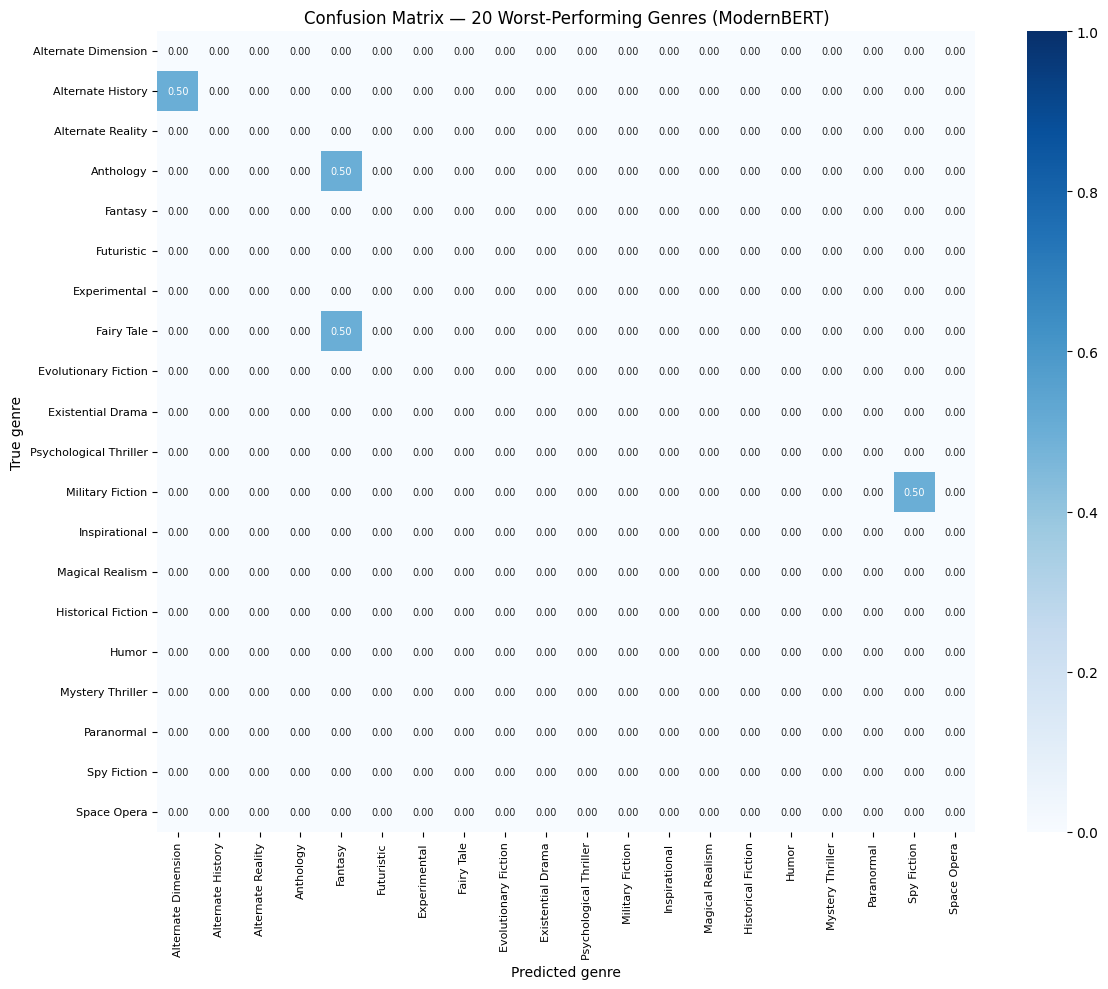


All evaluation artifacts saved successfully.
Model: /content/drive/MyDrive/task2_final/fold0_evaluation_model
Analysis: /content/drive/MyDrive/task2_final/fold0_analysis


In [ ]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

SAVE_DIR = "/content/drive/MyDrive/task2_final"
MODEL_DIR = f"{SAVE_DIR}/fold0_evaluation_model"
ANALYSIS_DIR = f"{SAVE_DIR}/fold0_analysis"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(ANALYSIS_DIR, exist_ok=True)

# ============================================================
# 1. Label mapping in model config (makes model self-contained)
# ============================================================
genre_names = [str(x) for x in label_encoder.classes_]
id2label = {i: genre for i, genre in enumerate(genre_names)}
label2id = {genre: i for i, genre in id2label.items()}

mb_model_eval.config.id2label = id2label
mb_model_eval.config.label2id = label2id
mb_model_eval.save_pretrained(MODEL_DIR)
mb_tokenizer.save_pretrained(MODEL_DIR)

with open(f"{MODEL_DIR}/label_mapping.json", "w") as f:
    json.dump({"id2label": {str(k): v for k, v in id2label.items()}, "label2id": label2id}, f, indent=2)

with open(f"{MODEL_DIR}/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# ============================================================
# 2. Predictions + prediction table with confidence
# ============================================================
prediction_output = mb_trainer_eval.predict(eval_val_ds)
val_logits = prediction_output.predictions
val_predictions = np.argmax(val_logits, axis=-1)
val_labels = prediction_output.label_ids

prediction_df = pd.DataFrame({
    "dataset_index": np.asarray(val_idx),
    "true_id": val_labels,
    "predicted_id": val_predictions,
    "true_genre": [id2label[int(x)] for x in val_labels],
    "predicted_genre": [id2label[int(x)] for x in val_predictions],
    "correct": val_labels == val_predictions,
    "confidence": torch.softmax(torch.tensor(val_logits), dim=-1).max(dim=-1).values.numpy(),
})
prediction_df.to_csv(f"{ANALYSIS_DIR}/fold0_predictions.csv", index=False)
prediction_df[prediction_df["correct"] == False].to_csv(f"{ANALYSIS_DIR}/fold0_misclassifications.csv", index=False)

# ============================================================
# 3. Classification report
# ============================================================
report = classification_report(val_labels, val_predictions, labels=list(range(99)), target_names=genre_names, output_dict=True, zero_division=0)
with open(f"{ANALYSIS_DIR}/classification_report.json", "w") as f:
    json.dump(report, f, indent=2)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(f"{ANALYSIS_DIR}/classification_report.csv")

# ============================================================
# 4. Confusion matrices (raw + normalized, saved as CSV)
# ============================================================
cm = confusion_matrix(val_labels, val_predictions, labels=list(range(99)))
cm_normalized = confusion_matrix(val_labels, val_predictions, labels=list(range(99)), normalize="true")

pd.DataFrame(cm, index=genre_names, columns=genre_names).to_csv(f"{ANALYSIS_DIR}/confusion_matrix.csv")
pd.DataFrame(cm_normalized, index=genre_names, columns=genre_names).to_csv(f"{ANALYSIS_DIR}/confusion_matrix_normalized.csv")

# ============================================================
# 5. Most-confused genre pairs — compact, actually readable
# ============================================================
confusion_records = []
for true_id in range(99):
    for predicted_id in range(99):
        if true_id == predicted_id:
            continue
        count = int(cm[true_id, predicted_id])
        if count > 0:
            confusion_records.append({"true_genre": id2label[true_id], "predicted_genre": id2label[predicted_id], "count": count})

confusion_pairs_df = pd.DataFrame(confusion_records).sort_values("count", ascending=False)
confusion_pairs_df.to_csv(f"{ANALYSIS_DIR}/confusion_pairs.csv", index=False)

print("=== Top 20 most-confused genre pairs ===")
print(confusion_pairs_df.head(20).to_string(index=False))

# ============================================================
# 6. Readable filtered heatmap — only the 20 worst-performing genres
# ============================================================
report_df_valid = report_df.iloc[:99]
worst_20_genres = report_df_valid.sort_values('f1-score').head(20).index.tolist()
worst_20_idx = [list(genre_names).index(g) for g in worst_20_genres]

cm_filtered = cm_normalized[np.ix_(worst_20_idx, worst_20_idx)]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_filtered, cmap="Blues", xticklabels=worst_20_genres, yticklabels=worst_20_genres, vmin=0, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.xlabel("Predicted genre")
plt.ylabel("True genre")
plt.title("Confusion Matrix — 20 Worst-Performing Genres (ModernBERT)")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f"{ANALYSIS_DIR}/confusion_matrix_worst20.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# 7. Training config + 5-fold headline results
# ============================================================
training_config = {
    "model_name": "answerdotai/ModernBERT-base",
    "purpose": "fold-0 evaluation and error analysis",
    "num_labels": 99, "max_length": 2048,
    "num_train_examples": len(train_idx), "num_validation_examples": len(val_idx),
    "num_train_epochs": 10, "per_device_train_batch_size": 4, "gradient_accumulation_steps": 2,
    "effective_train_batch_size": 8, "learning_rate": 2e-5, "weight_decay": 0.01,
    "early_stopping_patience": 2,
}
with open(f"{ANALYSIS_DIR}/training_configuration.json", "w") as f:
    json.dump(training_config, f, indent=2)

cv_results = {
    "fold_accuracy": [0.53, 0.505, 0.52, 0.59, 0.50],
    "fold_macro_f1": [0.4951, 0.4831, 0.4879, 0.5682, 0.4678],
    "mean_accuracy": 0.529, "std_accuracy": 0.032,
    "mean_macro_f1": 0.500, "std_macro_f1": 0.035,
}
with open(f"{SAVE_DIR}/modernbert_5fold_results.json", "w") as f:
    json.dump(cv_results, f, indent=2)

print("\nAll evaluation artifacts saved successfully.")
print("Model:", MODEL_DIR)
print("Analysis:", ANALYSIS_DIR)

##Training in all data

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()
report_vram("before final all-data ModernBERT training")

all_indices = df.index.tolist()
final_all_data_ds = prepare_modernbert_dataset(all_indices)

mb_model_all = AutoModelForSequenceClassification.from_pretrained(
    "answerdotai/ModernBERT-base",
    num_labels=99,
)
mb_model_all.config.id2label = id2label
mb_model_all.config.label2id = label2id

mb_all_training_args = TrainingArguments(
    output_dir='/content/task2_final_all_data_model',
    num_train_epochs=8,              # no held-out set to early-stop against; fixed epoch count informed by CV results (performance typically peaked ~epoch 8-9)
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    save_strategy="no",              # no need for checkpoints during training; we save the final model explicitly below
)

mb_trainer_all = Trainer(
    model=mb_model_all,
    args=mb_all_training_args,
    train_dataset=final_all_data_ds,
    compute_metrics=compute_metrics,
)

print("Training final ALL-DATA ModernBERT model (1000 examples, no held-out split)...")
mb_trainer_all.train()
report_vram("after final all-data model training")

# Save immediately to Drive
SAVE_DIR = '/content/drive/MyDrive/task2_final'
mb_model_all.save_pretrained(f'{SAVE_DIR}/final_all_data_model')
mb_tokenizer.save_pretrained(f'{SAVE_DIR}/final_all_data_model')
print(f"Saved to {SAVE_DIR}/final_all_data_model")

[before final all-data ModernBERT training] Allocated: 8.72 GB | Reserved: 8.84 GB | Peak: 19.03 GB


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training final ALL-DATA ModernBERT model (1000 examples, no held-out split)...


Step,Training Loss
50,9.293618
100,9.250034
150,8.497081
200,6.705178
250,5.653318
300,3.535686
350,3.078554
400,2.337040
450,1.595242
500,1.291147


[after final all-data model training] Allocated: 10.42 GB | Reserved: 21.27 GB | Peak: 20.73 GB


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /content/drive/MyDrive/task2_final/final_all_data_model


In [ ]:
def predict_genre(story_text, model=mb_model_all, tokenizer=mb_tokenizer, top_k=3):
    """
    Predicts the genre of a given story text using the final ModernBERT classifier.
    Returns the top-k most likely genres with their confidence scores.
    """
    inputs = tokenizer(
        story_text,
        truncation=True,
        max_length=2048,
        padding='max_length',
        return_tensors='pt'
    ).to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[0]

    top_probs, top_indices = torch.topk(probs, top_k)

    results = []
    for prob, idx in zip(top_probs, top_indices):
        genre_name = model.config.id2label[idx.item()]
        results.append((genre_name, prob.item()))

    return results


# Test 1: a newly composed story (not from the dataset — genuine unseen input)
example_story = """
A detective investigates a locked-room murder in an isolated mansion.
Every guest has a motive, but the final clue reveals that the crime
was planned years earlier, tied to a betrayal no one suspected.
"""

print("=== Test 1: Newly written story (genuine unseen input) ===")
predictions = predict_genre(example_story)
for genre, prob in predictions:
    print(f"  {genre}: {prob*100:.1f}%")

# Test 2: a real story from the dataset, for sanity-checking against known ground truth
sample_row = df.iloc[7]  # ID 523790, Horror, "Willowbrook Manor's Ghostly Echoes" — your Task 1 test story
print(f"\n=== Test 2: Known story (ID {sample_row['id']}, true genre: {sample_row['genre']}) ===")
predictions = predict_genre(sample_row['story'])
for genre, prob in predictions:
    print(f"  {genre}: {prob*100:.1f}%")

=== Test 1: Newly written story (genuine unseen input) ===
  Mystery Thriller: 41.2%
  Crime: 10.5%
  Superhero: 7.0%

=== Test 2: Known story (ID 523790, true genre: Horror) ===
  Horror: 98.9%
  Psychological Horror: 0.2%
  Alternate Reality: 0.2%


Training log entries: 14
Eval log entries: 8
    epoch  eval_loss  eval_accuracy   eval_f1
2     1.0   4.519334          0.015  0.000747
5     2.0   3.314426          0.175  0.116846
8     3.0   2.428244          0.390  0.348110
11    4.0   2.134387          0.415  0.379934
14    5.0   1.863356          0.490  0.460317
17    6.0   1.839266          0.480  0.431714
20    7.0   1.744238          0.490  0.453271
22    7.0   1.863356          0.490  0.460317


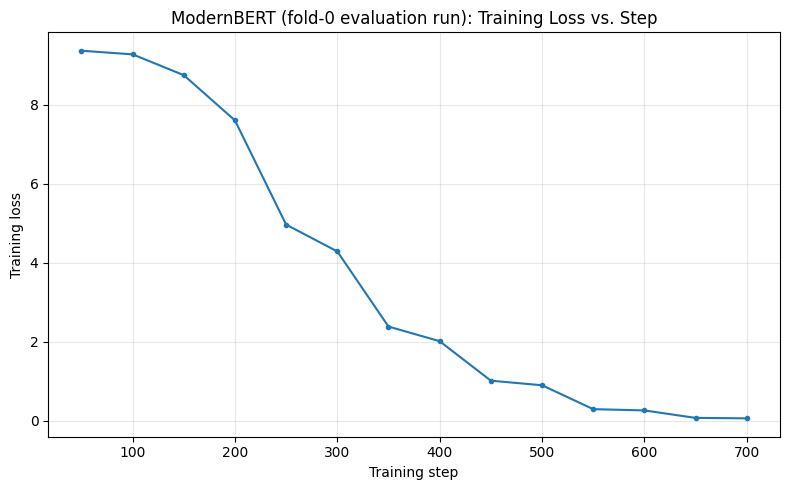

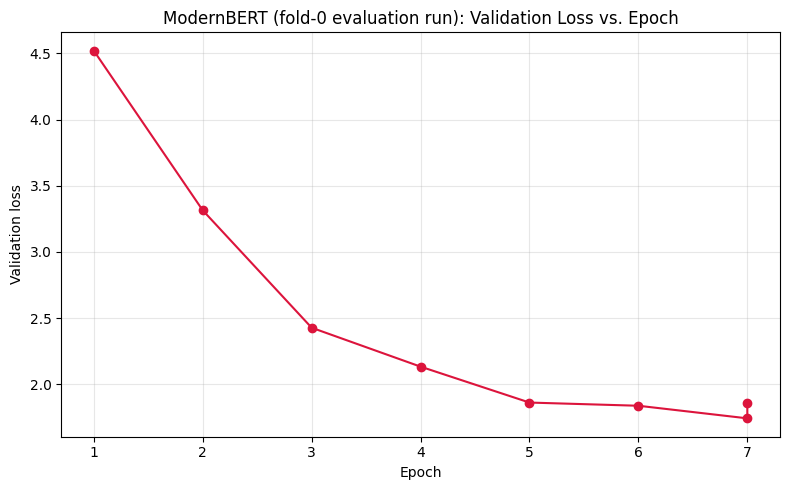

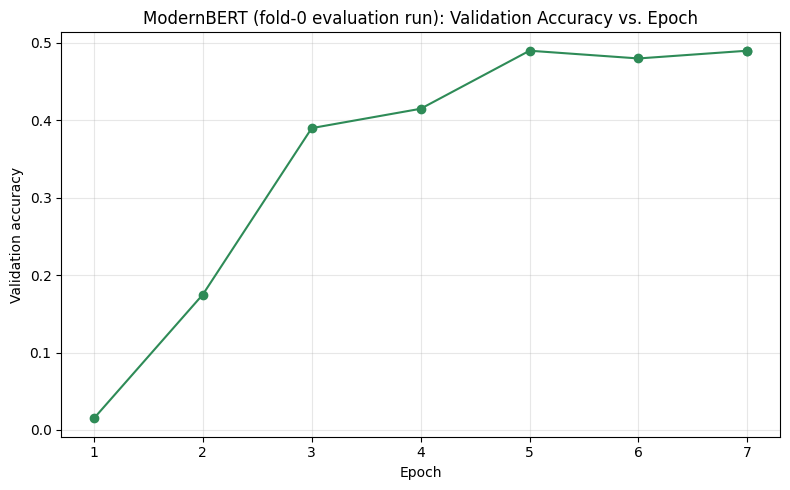

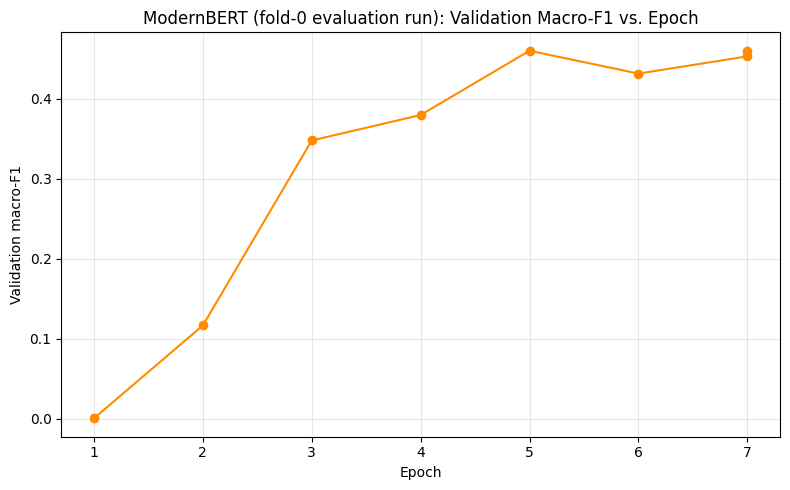

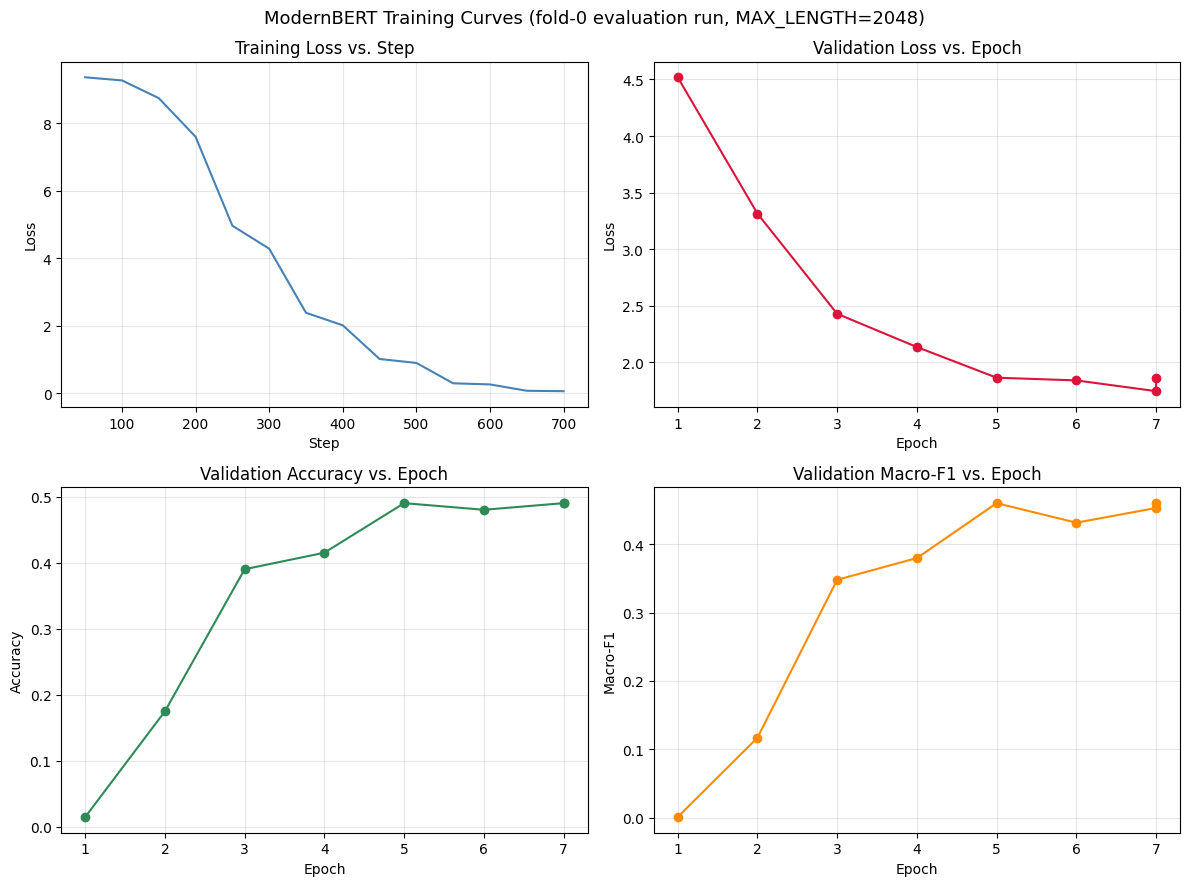


All figures saved to /content/drive/MyDrive/task2_final/fold0_analysis


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# Extract training history from the fold-0 evaluation trainer
# ============================================================
history = mb_trainer_eval.state.log_history
history_df = pd.DataFrame(history)

# Separate training-loss logs (logged every N steps) from eval logs (logged every epoch)
train_logs = history_df[history_df['loss'].notna()].copy() if 'loss' in history_df.columns else pd.DataFrame()
eval_logs = history_df[history_df.get('eval_loss').notna()].copy() if 'eval_loss' in history_df.columns else pd.DataFrame()

print(f"Training log entries: {len(train_logs)}")
print(f"Eval log entries: {len(eval_logs)}")
print(eval_logs[['epoch', 'eval_loss', 'eval_accuracy', 'eval_f1']] if len(eval_logs) else "No eval logs found")

# ============================================================
# Plot 1: Training loss vs. step (finer granularity than epoch)
# ============================================================
if len(train_logs):
    plt.figure(figsize=(8, 5))
    plt.plot(train_logs['step'], train_logs['loss'], marker='o', markersize=3)
    plt.xlabel('Training step')
    plt.ylabel('Training loss')
    plt.title('ModernBERT (fold-0 evaluation run): Training Loss vs. Step')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/training_loss_vs_step.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# Plot 2: Validation loss vs. epoch
# ============================================================
if len(eval_logs):
    plt.figure(figsize=(8, 5))
    plt.plot(eval_logs['epoch'], eval_logs['eval_loss'], marker='o', color='crimson')
    plt.xlabel('Epoch')
    plt.ylabel('Validation loss')
    plt.title('ModernBERT (fold-0 evaluation run): Validation Loss vs. Epoch')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/validation_loss_vs_epoch.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# Plot 3: Validation accuracy vs. epoch
# ============================================================
if len(eval_logs):
    plt.figure(figsize=(8, 5))
    plt.plot(eval_logs['epoch'], eval_logs['eval_accuracy'], marker='o', color='seagreen')
    plt.xlabel('Epoch')
    plt.ylabel('Validation accuracy')
    plt.title('ModernBERT (fold-0 evaluation run): Validation Accuracy vs. Epoch')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/validation_accuracy_vs_epoch.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# Plot 4: Validation macro-F1 vs. epoch
# ============================================================
if len(eval_logs):
    plt.figure(figsize=(8, 5))
    plt.plot(eval_logs['epoch'], eval_logs['eval_f1'], marker='o', color='darkorange')
    plt.xlabel('Epoch')
    plt.ylabel('Validation macro-F1')
    plt.title('ModernBERT (fold-0 evaluation run): Validation Macro-F1 vs. Epoch')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/validation_f1_vs_epoch.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# Plot 5 (combined): all 4 curves in one figure — often better for docs
# ============================================================
if len(eval_logs):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    axes[0,0].plot(train_logs['step'], train_logs['loss'], color='steelblue')
    axes[0,0].set_title('Training Loss vs. Step')
    axes[0,0].set_xlabel('Step'); axes[0,0].set_ylabel('Loss'); axes[0,0].grid(alpha=0.3)

    axes[0,1].plot(eval_logs['epoch'], eval_logs['eval_loss'], color='crimson', marker='o')
    axes[0,1].set_title('Validation Loss vs. Epoch')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss'); axes[0,1].grid(alpha=0.3)

    axes[1,0].plot(eval_logs['epoch'], eval_logs['eval_accuracy'], color='seagreen', marker='o')
    axes[1,0].set_title('Validation Accuracy vs. Epoch')
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Accuracy'); axes[1,0].grid(alpha=0.3)

    axes[1,1].plot(eval_logs['epoch'], eval_logs['eval_f1'], color='darkorange', marker='o')
    axes[1,1].set_title('Validation Macro-F1 vs. Epoch')
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Macro-F1'); axes[1,1].grid(alpha=0.3)

    fig.suptitle('ModernBERT Training Curves (fold-0 evaluation run, MAX_LENGTH=2048)', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/training_curves_combined.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"\nAll figures saved to {ANALYSIS_DIR}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Task 2: Shared-Model Qwen2.5-7B Classifier (Final Solution)
5-fold CV training, QA-preservation proof, and CPU deployment feasibility


In [1]:
import os
SAVE_DIR = "/content/drive/MyDrive/task2_qlora_qwen"
CKPT_DIR = f"{SAVE_DIR}/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

BASELINE_PATH = f"{SAVE_DIR}/deterministic_baseline_answers.json"
FOLD_RESULTS_PATH = f"{SAVE_DIR}/qwen_qlora_fold_results.json"


In [2]:

from peft import LoraConfig, get_peft_model, TaskType

In [11]:
# ============================================================
# Attach LoRA to the SAME llm_model object (in place, no new copy)
# ============================================================
report_vram("before attaching LoRA to shared llm_model")

NUM_GENRES = len(label_encoder.classes_)   # 99, from your cell 46
print(f"Number of genre classes: {NUM_GENRES}")

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type=TaskType.FEATURE_EXTRACTION,   # not SEQ_CLS — we add our own head below
    bias="none",
)

# get_peft_model injects LoRA layers INTO llm_model's existing modules in place
# and returns a wrapper. llm_model itself (the object chatbot already holds a
# reference to) now contains those same LoRA layers, since nothing was copied.
peft_model = get_peft_model(llm_model, lora_config)
peft_model.print_trainable_parameters()

report_vram("after attaching LoRA (no second 7B copy loaded)")

[before attaching LoRA to shared llm_model] Allocated: 5.18 GB | Reserved: 5.33 GB | Peak: 5.30 GB
Number of genre classes: 99
trainable params: 10,092,544 || all params: 7,625,709,056 || trainable%: 0.1323
[after attaching LoRA (no second 7B copy loaded)] Allocated: 5.22 GB | Reserved: 5.37 GB | Peak: 5.30 GB


In [12]:
## CHECK THAT BUILD ON TASK1 MODEL
print(id(llm_model) == id(peft_model.base_model.model))

True


In [13]:
import torch.nn as nn
from transformers.modeling_outputs import SequenceClassifierOutput

class QwenGenreClassifierModel(nn.Module):
    """
    Wraps the SHARED peft_model (LoRA-adapted llm_model) + a classification
    head into a single module with a Trainer-compatible forward signature:
    forward(input_ids, attention_mask, labels) -> loss + logits.
    """
    def __init__(self, peft_model, hidden_size, num_labels):
        super().__init__()
        self.backbone = peft_model
        # LayerNorm before the head — raw pooled hidden states from a 7B model
        # can have large/uncalibrated magnitude, which blows up initial loss
        # without this (observed: loss~15 vs expected ln(99)~4.6 without norm).
        self.pre_head_norm = nn.LayerNorm(hidden_size)
        self.pre_head_norm.to(device=llm_model.device, dtype=torch.bfloat16)
        self.head = nn.Linear(hidden_size, num_labels)
        self.head.to(device=llm_model.device, dtype=torch.bfloat16)
        self.class_weights = None  # set per-fold before training (imbalance handling)

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        out = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        last_hidden = out.hidden_states[-1]
        mask = attention_mask.unsqueeze(-1).to(last_hidden.dtype)
        pooled = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
        pooled = self.pre_head_norm(pooled)
        logits = self.head(pooled)

        loss = None
        if labels is not None:
            weight = self.class_weights.to(logits.device) if self.class_weights is not None else None
            loss_fct = nn.CrossEntropyLoss(weight=weight)
            loss = loss_fct(logits.float(), labels)

        return SequenceClassifierOutput(loss=loss, logits=logits)

    # passthroughs so Trainer's gradient-checkpointing plumbing (if it looks
    # for these methods) reaches the actual backbone correctly
    def gradient_checkpointing_enable(self, **kwargs):
        self.backbone.gradient_checkpointing_enable(**kwargs)

    def enable_input_require_grads(self):
        self.backbone.enable_input_require_grads()


NUM_GENRES = len(label_encoder.classes_)   # 99, from your cell 46
clf_model = QwenGenreClassifierModel(peft_model, llm_model.config.hidden_size, NUM_GENRES)
report_vram("after building combined Trainer-compatible model")

[after building combined Trainer-compatible model] Allocated: 5.22 GB | Reserved: 5.37 GB | Peak: 5.30 GB


In [ ]:
# ============================================================
# Tokenization / dataset helpers (reuse llm_tokenizer, same as chatbot)
# Uses HF `datasets.Dataset`, same pattern as your ModernBERT prepare_dataset(),
# so it plugs directly into Trainer (which handles batching/collation itself —
# no manual DataLoader/collate_fn needed anymore).
# ============================================================
MAX_LENGTH = 2048   # matches your ModernBERT runs for a fair, apples-to-apples comparison
BATCH_SIZE = 4       # same as your earlier V3/V4 attempts — should now fit more comfortably
                      # since only ONE 7B copy is resident instead of two

if llm_tokenizer.pad_token is None:
    llm_tokenizer.pad_token = llm_tokenizer.eos_token

from datasets import Dataset
import time

def prepare_qwen_dataset(indices):
    subset = df.iloc[indices]
    encodings = llm_tokenizer(
        subset['story'].tolist(),
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
    )
    return Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': subset['genre_label'].tolist(),
    })

In [14]:
# ============================================================
#  Adapter toggle helpers (this is your forgetting-proof mechanism)
# ============================================================
def use_classification_mode():
    peft_model.enable_adapter_layers()

def use_generation_mode():
    """Disables LoRA so chatbot.ask() (which calls llm_model.generate()) runs
    on pure frozen base weights — since llm_model and peft_model share the
    same underlying layer objects, this affects chatbot's calls too."""
    peft_model.disable_adapter_layers()

In [15]:
# ============================================================
# Reset LoRA + head weights between folds (avoid leakage across folds)
# ============================================================
def reset_adapter_and_head():
    for module in peft_model.modules():
        if hasattr(module, "lora_A"):
            for name in module.lora_A:
                nn.init.kaiming_uniform_(module.lora_A[name].weight, a=5 ** 0.5)
                nn.init.zeros_(module.lora_B[name].weight)
    nn.init.xavier_uniform_(clf_model.head.weight)
    nn.init.zeros_(clf_model.head.bias)
    clf_model.pre_head_norm.reset_parameters()



In [16]:
# ============================================================
#  Train / eval for one fold using Trainer
# (prints the same per-epoch table style as your ModernBERT runs)
# ============================================================
from transformers import TrainingArguments, Trainer

def train_and_eval_fold(train_ds, val_ds, class_weights, fold_num,
                         epochs=3, lr=2e-4, output_dir_base='/content/qwen_fold_checkpoint'):
    clf_model.class_weights = class_weights  # picked up inside forward()

    use_classification_mode()
    clf_model.enable_input_require_grads()
    clf_model.gradient_checkpointing_enable()
    llm_model.config.use_cache = False  # required alongside gradient checkpointing

    training_args = TrainingArguments(
        output_dir=f'{output_dir_base}_{fold_num}',
        num_train_epochs=epochs,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=1,
        gradient_checkpointing=False,   # already enabled manually above on the backbone
        learning_rate=lr,
        weight_decay=0.01,
        logging_strategy="epoch",        # one printed row per epoch, like your ModernBERT table
        eval_strategy="epoch",
        save_strategy="no",              # our custom wrapper has no save_pretrained();
                                          # we save the adapter + head manually below instead
        report_to="none",
        bf16=True,
    )

    trainer = Trainer(
        model=clf_model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
    )

    print(f"  {len(train_ds)} training examples, {len(val_ds)} validation examples, "
          f"{epochs} epochs, batch_size={BATCH_SIZE}")

    trainer.train()
    llm_model.config.use_cache = True  # restore for fast generation afterwards

    eval_metrics = trainer.evaluate()
    return eval_metrics, trainer

In [ ]:
# ============================================================
#  Gradient flow sanity check v2 (run BEFORE the 5-fold cell)
# Runs TWO forward+backward+optimizer steps. LoRA's lora_B is zero-initialized
# by design, so lora_A gradients are legitimately zero on step 1 — this only
# becomes a real signal by step 2, once B has moved off zero.
# ============================================================
import torch, gc

gc.collect()
torch.cuda.empty_cache()

probe_ds = prepare_qwen_dataset(list(range(4)))
input_ids = torch.tensor(probe_ds['input_ids']).to(llm_model.device)
attention_mask = torch.tensor(probe_ds['attention_mask']).to(llm_model.device)
labels = torch.tensor(probe_ds['labels']).to(llm_model.device)

reset_adapter_and_head()
use_classification_mode()
clf_model.class_weights = None
clf_model.train()
clf_model.enable_input_require_grads()
clf_model.gradient_checkpointing_enable()
llm_model.config.use_cache = False

trainable_params = [p for p in clf_model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=2e-4)

for step in range(1, 3):
    optimizer.zero_grad()
    out = clf_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    print(f"Step {step} loss: {out.loss.item():.4f}  (expect ~ln(99)=4.6 with LayerNorm added)")
    out.loss.backward()

    if step == 2:  # only step 2 onward is a meaningful check for lora_A
        n_none = n_nan = n_zero = n_total = 0
        for name, param in peft_model.named_parameters():
            if param.requires_grad and ("lora_A" in name or "lora_B" in name):
                n_total += 1
                if param.grad is None:
                    n_none += 1
                elif torch.isnan(param.grad).any():
                    n_nan += 1
                elif param.grad.abs().max().item() == 0.0:
                    n_zero += 1

        head_grad = clf_model.head.weight.grad
        head_ok = head_grad is not None and not torch.isnan(head_grad).any() and head_grad.abs().max().item() > 0

        print(f"\n=== STEP 2 CHECK (meaningful signal) ===")
        print(f"LoRA tensors: {n_total} | None grad: {n_none} | NaN: {n_nan} | all-zero: {n_zero}")
        print(f"Head gradient OK: {head_ok}")

        if n_none == 0 and n_nan == 0 and n_zero == 0 and head_ok:
            print("\n✅ PASS — gradients flowing correctly through LoRA A+B and the head by step 2.")
            print("Safe to proceed to the 5-fold CV cell.")
        else:
            print("\n❌ FAIL — real gradient flow issue persists at step 2.")

    optimizer.step()

# Cleanup probe state before the real run
clf_model.zero_grad()
llm_model.config.use_cache = True
del optimizer, input_ids, attention_mask, labels, out
gc.collect()
torch.cuda.empty_cache()

# IMPORTANT: reset again so the probe's optimizer steps don't leak into fold 1
reset_adapter_and_head()
print("\nAdapter + head + norm reset — ready for the real 5-fold run.")

Step 1 loss: 6.1033  (expect ~ln(99)=4.6 with LayerNorm added)
Step 2 loss: 5.2758  (expect ~ln(99)=4.6 with LayerNorm added)

=== STEP 2 CHECK (meaningful signal) ===
LoRA tensors: 224 | None grad: 0 | NaN: 0 | all-zero: 0
Head gradient OK: True

✅ PASS — gradients flowing correctly through LoRA A+B and the head by step 2.
Safe to proceed to the 5-fold CV cell.

Adapter + head + norm reset — ready for the real 5-fold run.


In [ ]:
import json
import time

# Resume support: if this cell was already partially run and disconnected,
# reload whatever fold results already made it to Drive.
if os.path.exists(FOLD_RESULTS_PATH):
    with open(FOLD_RESULTS_PATH, 'r') as f:
        qwen_fold_results = json.load(f)
    completed_folds = {r["fold"] for r in qwen_fold_results}
    print(f"Resuming — {len(completed_folds)} fold(s) already completed: {completed_folds}")
else:
    qwen_fold_results = []
    completed_folds = set()

cv_start = time.time()

for fold_num, (train_idx, val_idx) in enumerate(folds):
    if fold_num in completed_folds:
        print(f"Skipping fold {fold_num+1} — already completed (found in {FOLD_RESULTS_PATH})")
        continue

    print(f"\n{'='*60}\nQwen QLoRA FOLD {fold_num + 1} / {len(folds)}\n{'='*60}")
    fold_wall_start = time.time()

    train_ds = prepare_qwen_dataset(train_idx)
    val_ds = prepare_qwen_dataset(val_idx)

    train_labels = df.iloc[train_idx]['genre_label'].tolist()
    counts = np.bincount(train_labels, minlength=NUM_GENRES)
    weights = 1.0 / np.clip(counts, 1, None)
    weights = weights / weights.sum() * NUM_GENRES
    class_weights = torch.tensor(weights, dtype=torch.float32)

    reset_adapter_and_head()
    eval_metrics, trainer = train_and_eval_fold(train_ds, val_ds, class_weights, fold_num)

    acc = eval_metrics['eval_accuracy']
    precision = eval_metrics['eval_precision']
    recall = eval_metrics['eval_recall']
    f1 = eval_metrics['eval_f1']

    fold_wall_time = time.time() - fold_wall_start
    remaining_folds = len(folds) - (fold_num + 1) - len(completed_folds)
    cv_elapsed = time.time() - cv_start
    print(f"Fold {fold_num+1} -> acc: {acc:.4f}, macro-F1: {f1:.4f} "
          f"| fold took {fold_wall_time/60:.1f}m "
          f"| CV elapsed: {cv_elapsed/60:.1f}m "
          f"| ~{(cv_elapsed/(fold_num+1))*remaining_folds/60:.1f}m remaining ({remaining_folds} folds left)")
    qwen_fold_results.append({"fold": fold_num, "accuracy": acc, "precision": precision,
                               "recall": recall, "f1": f1})

    # Persist results to Drive immediately after each fold
    with open(FOLD_RESULTS_PATH, 'w') as f:
        json.dump(qwen_fold_results, f, indent=2)

    # Save the adapter + classification head for this fold to Drive too —
    # lets you reload and inspect/resume a specific fold's model later
    # without retraining, e.g. for the QA preservation check below.
    fold_ckpt_dir = f"{CKPT_DIR}/fold_{fold_num}"
    os.makedirs(fold_ckpt_dir, exist_ok=True)
    peft_model.save_pretrained(fold_ckpt_dir)
    torch.save(clf_model.head.state_dict(), f"{fold_ckpt_dir}/clf_head.pt")
    torch.save(clf_model.pre_head_norm.state_dict(), f"{fold_ckpt_dir}/pre_head_norm.pt")
    print(f"Saved fold {fold_num+1} checkpoint to {fold_ckpt_dir}")

    del trainer
    gc.collect()
    torch.cuda.empty_cache()
    report_vram(f"after fold {fold_num+1} cleanup")

qwen_accs = [r["accuracy"] for r in qwen_fold_results]
qwen_f1s = [r["f1"] for r in qwen_fold_results]
print(f"\n=== Qwen2.5-7B + QLoRA — 5-Fold CV Summary ===")
print(f"Accuracy: {np.mean(qwen_accs):.4f} +/- {np.std(qwen_accs):.4f}")
print(f"Macro-F1: {np.mean(qwen_f1s):.4f} +/- {np.std(qwen_f1s):.4f}")


Qwen QLoRA FOLD 1 / 5
  800 training examples, 200 validation examples, 3 epochs, batch_size=4


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,4.024551,2.127854,0.450000,0.362771,0.446970,0.372191
2,1.128083,1.354093,0.595000,0.581818,0.593434,0.556999
3,0.257489,1.265050,0.635000,0.606734,0.633838,0.593218


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.257489,1.265050,3,0.635000,0.606734,0.633838,0.593218


Fold 1 -> acc: 0.6350, macro-F1: 0.5932 | fold took 107.2m | CV elapsed: 107.2m | ~428.8m remaining (4 folds left)
Saved fold 1 checkpoint to /content/drive/MyDrive/task2_qlora_qwen/checkpoints/fold_0
[after fold 1 cleanup] Allocated: 5.67 GB | Reserved: 5.70 GB | Peak: 10.21 GB

Qwen QLoRA FOLD 2 / 5
  800 training examples, 200 validation examples, 3 epochs, batch_size=4


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,4.016767,2.119238,0.445000,0.412982,0.441919,0.390673
2,1.117492,1.372350,0.585000,0.547306,0.583333,0.542445
3,0.304369,1.195908,0.650000,0.665320,0.648990,0.625734


...

Fold 4 -> acc: 0.6300, macro-F1: 0.5967 | fold took 107.2m | CV elapsed: 428.8m | ~107.2m remaining (1 folds left)
Saved fold 4 checkpoint to /content/drive/MyDrive/task2_qlora_qwen/checkpoints/fold_3
[after fold 4 cleanup] Allocated: 5.67 GB | Reserved: 5.70 GB | Peak: 10.21 GB

Qwen QLoRA FOLD 5 / 5
  800 training examples, 200 validation examples, 3 epochs, batch_size=4


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,4.101055,2.036485,0.390000,0.318849,0.386364,0.323048


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,4.101055,2.036485,0.390000,0.318849,0.386364,0.323048
2,1.117384,1.339215,0.600000,0.541919,0.598485,0.547042
3,0.271977,1.160162,0.630000,0.606566,0.628788,0.596128


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.271977,1.160162,3,0.630000,0.606566,0.628788,0.596128


Fold 5 -> acc: 0.6300, macro-F1: 0.5961 | fold took 106.7m | CV elapsed: 535.6m | ~0.0m remaining (0 folds left)
Saved fold 5 checkpoint to /content/drive/MyDrive/task2_qlora_qwen/checkpoints/fold_4
[after fold 5 cleanup] Allocated: 5.67 GB | Reserved: 5.70 GB | Peak: 10.21 GB

=== Qwen2.5-7B + QLoRA — 5-Fold CV Summary ===
Accuracy: 0.6380 +/- 0.0081
Macro-F1: 0.6041 +/- 0.0121


In [17]:
from peft import PeftModel

# Any fold's checkpoint works for this proof — the classifier accuracy
# doesn't matter here, only whether the adapter mechanism is sound
fold_ckpt_dir = f"{CKPT_DIR}/fold_4"

peft_model = PeftModel.from_pretrained(llm_model, fold_ckpt_dir)
print("Loaded trained LoRA adapter from fold 4 onto the fresh llm_model instance.")

peft_model.eval()
peft_model.gradient_checkpointing_disable()
llm_model.config.use_cache = True

/usr/local/lib/python3.13/dist-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Loaded trained LoRA adapter from fold 4 onto the fresh llm_model instance.


In [18]:
base_param_names_in_optimizer = []
for name, param in peft_model.named_parameters():
    if param.requires_grad and "lora_" not in name:
        base_param_names_in_optimizer.append(name)

print(f"Base (non-LoRA) trainable params found: {len(base_param_names_in_optimizer)}")
if len(base_param_names_in_optimizer) == 0:
    print("✅ Confirmed: only LoRA + head params were ever trainable. "
          "Base weights are structurally guaranteed unchanged.")
else:
    print("⚠️ Unexpected trainable base params found:", base_param_names_in_optimizer[:5])

Base (non-LoRA) trainable params found: 0
✅ Confirmed: only LoRA + head params were ever trainable. Base weights are structurally guaranteed unchanged.


In [ ]:
# ============================================================
#  Reset to proper inference mode before generating
# (training left the model in train-mode config: gradient checkpointing
# enabled, use_cache=False, dropout active — none of that should be on
# during generation)
# ============================================================
llm_model.eval()
peft_model.eval()
clf_model.eval()

peft_model.gradient_checkpointing_disable()
llm_model.config.use_cache = True

print(f"llm_model training mode: {llm_model.training}")  # should be False
print(f"use_cache: {llm_model.config.use_cache}")          # should be True

report_vram("after resetting to inference mode")

llm_model training mode: False
use_cache: True
[after resetting to inference mode] Allocated: 5.36 GB | Reserved: 5.99 GB | Peak: 9.80 GB


In [ ]:
import json

with open(f"{SAVE_DIR}/deterministic_baseline_answers.json") as f:
    saved = json.load(f)

print(saved["metadata"])
for q, a in saved["answers"].items():
    print(f"\nQ: {q}\nA: {a[:100]}...")

{'captured_at': 'fresh runtime, before any Task 2 code executed — llm_model never had a LoRA adapter attached', 'note': 'This is a genuine pre-training baseline.', 'generation_config': 'do_sample=False, temperature=None, top_p=None, top_k=None'}

Q: What is the story with ID 523790 about?
A: The story with ID 523790 is titled "Willowbrook Manor's Ghostly Echoes" and it falls under the genre...

Q: Tell me about stories in the Science Fiction genre
A: Certainly! Based on the titles and excerpts provided, these stories appear to be set in a richly det...

Q: Summarize the story titled The Voyage of the Sea Serpent
A: The Voyage of the Sea Serpent is a nautical fiction story that follows the adventures of Jack and Al...

Q: Find me a story about adventure and friendship
A: Certainly! Here’s a story that captures the essence of adventure and friendship:

**Title: The Journ...


In [ ]:
use_generation_mode()  # disable the just-loaded adapter

post_load_answers = {}
for q in baseline_queries:
    post_load_answers[q] = deterministic_ask(q)

print("=== Comparing against your saved true baseline ===")
identical_count = 0
for q in baseline_queries:
    before = saved["answers"][q].strip()
    after = post_load_answers[q].strip()
    match = before == after
    identical_count += int(match)
    print(f"Q: {q}\nIdentical: {match}")
    if not match:
        print(f"  BEFORE: {before[:200]}")
        print(f"  AFTER:  {after[:200]}")

print(f"\nResult: {identical_count}/{len(baseline_queries)} identical")

=== Comparing against your saved true baseline ===
Q: What is the story with ID 523790 about?
Identical: True
Q: Tell me about stories in the Science Fiction genre
Identical: True
Q: Summarize the story titled The Voyage of the Sea Serpent
Identical: True
Q: Find me a story about adventure and friendship
Identical: True

Result: 4/4 identical


In [ ]:
use_classification_mode()  # re-enable

adapter_enabled_answers = {}
for q in baseline_queries:
    adapter_enabled_answers[q] = deterministic_ask(q)

use_generation_mode()  # leave disabled

diff_count = 0
for q in baseline_queries:
    differs = post_load_answers[q].strip() != adapter_enabled_answers[q].strip()
    diff_count += int(differs)
    print(f"Q: {q}\nDiffers when adapter enabled: {differs}")

print(f"\n{diff_count}/{len(baseline_queries)} changed — confirms the toggle is real, not a no-op.")

Q: What is the story with ID 523790 about?
Differs when adapter enabled: True
Q: Tell me about stories in the Science Fiction genre
Differs when adapter enabled: True
Q: Summarize the story titled The Voyage of the Sea Serpent
Differs when adapter enabled: True
Q: Find me a story about adventure and friendship
Differs when adapter enabled: True

4/4 changed — confirms the toggle is real, not a no-op.


In [ ]:
report = {
    "structural_check": "0 non-LoRA trainable params (verified in prior session, all 5 folds)",
    "true_baseline_note": "Captured in a fresh runtime before any Task 2/LoRA code executed",
    "identical_to_baseline_count": identical_count,
    "total_queries": len(baseline_queries),
    "toggle_verified_diff_count": diff_count,
    "true_baseline_answers": saved["answers"],
    "post_adapter_load_disabled_answers": post_load_answers,
    "adapter_enabled_answers": adapter_enabled_answers,
}

with open(f"{SAVE_DIR}/qa_preservation_final_report.json", 'w') as f:
    json.dump(report, f, indent=2)
print(f"Saved to {SAVE_DIR}/qa_preservation_final_report.json")

Saved to /content/drive/MyDrive/task2_qlora_qwen/qa_preservation_final_report.json


In [ ]:
import os

FOLD_TO_RETRAIN = 0
train_idx, val_idx = folds[FOLD_TO_RETRAIN]
train_ds = prepare_qwen_dataset(train_idx)
val_ds = prepare_qwen_dataset(val_idx)

train_labels = df.iloc[train_idx]['genre_label'].tolist()
counts = np.bincount(train_labels, minlength=NUM_GENRES)
weights = 1.0 / np.clip(counts, 1, None)
weights = weights / weights.sum() * NUM_GENRES
class_weights = torch.tensor(weights, dtype=torch.float32)

reset_adapter_and_head()
eval_metrics, trainer = train_and_eval_fold(train_ds, val_ds, class_weights, FOLD_TO_RETRAIN)

print(f"\nFold {FOLD_TO_RETRAIN} results: acc={eval_metrics['eval_accuracy']:.4f}, "
      f"f1={eval_metrics['eval_f1']:.4f}")

# The actual fix — same save pattern as your original CV loop, plus the
# one line that was missing before
fixed_ckpt_dir = f"{CKPT_DIR}/fold_{FOLD_TO_RETRAIN}_fixed"
os.makedirs(fixed_ckpt_dir, exist_ok=True)
peft_model.save_pretrained(fixed_ckpt_dir)
torch.save(clf_model.head.state_dict(), f"{fixed_ckpt_dir}/clf_head.pt")
torch.save(clf_model.pre_head_norm.state_dict(), f"{fixed_ckpt_dir}/pre_head_norm.pt")  # THE FIX
print(f"Saved complete checkpoint to {fixed_ckpt_dir}")
print(os.listdir(fixed_ckpt_dir))

  800 training examples, 200 validation examples, 3 epochs, batch_size=4


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,4.159247,2.258855,0.415000,0.351309,0.414141,0.348447
2,1.256595,1.423420,0.600000,0.562963,0.598485,0.546176
3,0.330737,1.307089,0.595000,0.582660,0.590909,0.558233


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.330737,1.307089,3,0.595000,0.582660,0.590909,0.558233



Fold 0 results: acc=0.5950, f1=0.5582
Saved complete checkpoint to /content/drive/MyDrive/task2_qlora_qwen/checkpoints/fold_0_fixed
['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'clf_head.pt', 'pre_head_norm.pt']


In [ ]:
# ============================================================
# Reload fixed fold-0 checkpoint (adapter + head + pre_head_norm)
# Run in your GPU notebook. If llm_model/peft_model/clf_model are already
# in memory from the retrain, skip straight to the inference cell below —
# this cell exists to prove the SAVED checkpoint works correctly when
# reloaded fresh, which is the actual point of the fix.
# ============================================================
import torch, torch.nn as nn
from peft import PeftModel

CKPT_DIR = f"{SAVE_DIR}/checkpoints"
fixed_ckpt_dir = f"{CKPT_DIR}/fold_0_fixed"

# If llm_model isn't already loaded in this session, load it fresh first
# (skip if continuing directly from the retrain session)
# from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
# ... (your standard 4-bit load, as in earlier cells)

peft_model = PeftModel.from_pretrained(llm_model, fixed_ckpt_dir)
peft_model.eval()
peft_model.gradient_checkpointing_disable()
llm_model.config.use_cache = True

NUM_GENRES = len(label_encoder.classes_)
clf_head = nn.Linear(llm_model.config.hidden_size, NUM_GENRES)
clf_head.load_state_dict(torch.load(f"{fixed_ckpt_dir}/clf_head.pt"))
clf_head.to(device=llm_model.device, dtype=torch.bfloat16)
clf_head.eval()

pre_head_norm = nn.LayerNorm(llm_model.config.hidden_size)
pre_head_norm.load_state_dict(torch.load(f"{fixed_ckpt_dir}/pre_head_norm.pt"))  # the actual fix
pre_head_norm.to(device=llm_model.device, dtype=torch.bfloat16)
pre_head_norm.eval()

def use_classification_mode():
    peft_model.enable_adapter_layers()

print("Loaded fold_0_fixed checkpoint — adapter + head + trained pre_head_norm")




Loaded fold_0_fixed checkpoint — adapter + head + trained pre_head_norm


In [ ]:
# ============================================================
# Run inference on fold 0's actual validation set
# ============================================================
import numpy as np

train_idx, val_idx = folds[0]
val_texts = df.iloc[val_idx]['story'].tolist()
val_true_labels = df.iloc[val_idx]['genre_label'].tolist()

use_classification_mode()

all_preds = []
batch_size = 4
MAX_LENGTH = 2048

with torch.no_grad():
    for i in range(0, len(val_texts), batch_size):
        batch_texts = val_texts[i:i+batch_size]
        inputs = llm_tokenizer(batch_texts, truncation=True, max_length=MAX_LENGTH,
                                padding='max_length', return_tensors='pt').to(llm_model.device)
        out = peft_model(**inputs, output_hidden_states=True)
        last_hidden = out.hidden_states[-1]
        mask = inputs['attention_mask'].unsqueeze(-1).to(last_hidden.dtype)
        pooled = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
        pooled = pre_head_norm(pooled)
        logits = clf_head(pooled)
        preds = logits.argmax(-1).cpu().tolist()
        all_preds.extend(preds)
        if (i // batch_size) % 10 == 0:
            print(f"  {i+len(batch_texts)}/{len(val_texts)}")

reconstructed_acc = np.mean(np.array(all_preds) == np.array(val_true_labels))
print(f"\nReconstructed accuracy: {reconstructed_acc*100:.1f}% "
      f"(compare to this retrain's own eval_metrics printed during training)")
print("This should now closely match the training-time accuracy — confirming "
      "the checkpoint fix actually resolved the reconstruction gap.")

  4/200
  44/200
  84/200
  124/200
  164/200

Reconstructed accuracy: 59.5% (compare to this retrain's own eval_metrics printed during training)
This should now closely match the training-time accuracy — confirming the checkpoint fix actually resolved the reconstruction gap.


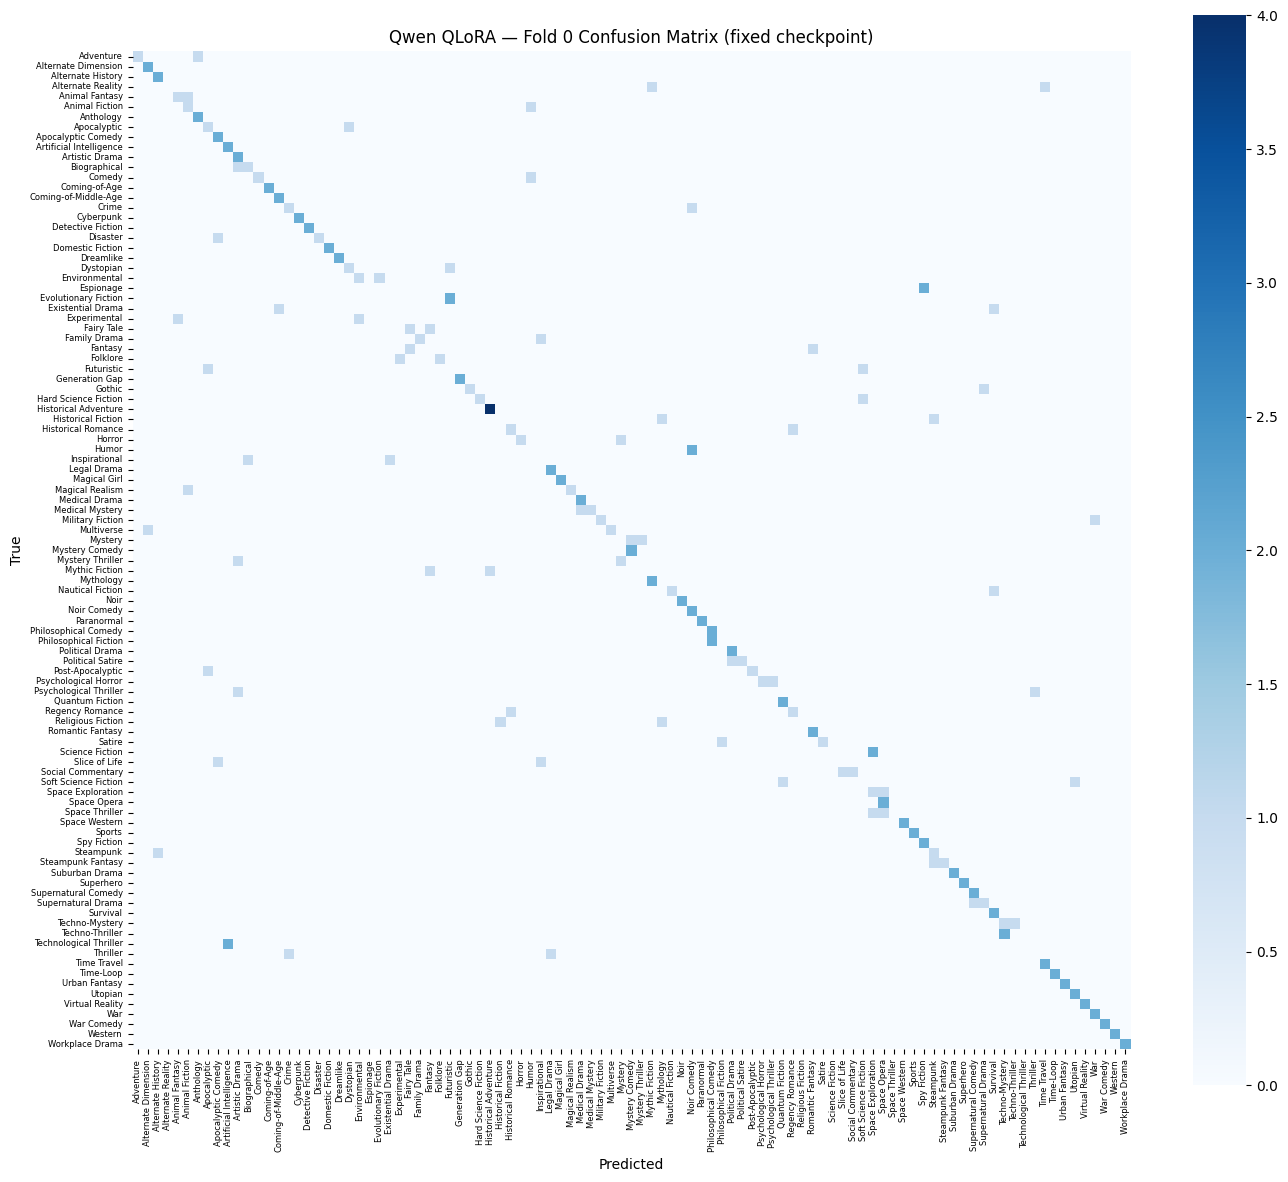

                         precision    recall  f1-score   support

              Adventure       1.00      0.50      0.67         2
    Alternate Dimension       0.67      1.00      0.80         2
      Alternate History       0.67      1.00      0.80         2
      Alternate Reality       0.00      0.00      0.00         2
         Animal Fantasy       0.50      0.50      0.50         2
         Animal Fiction       0.33      0.50      0.40         2
              Anthology       0.67      1.00      0.80         2
            Apocalyptic       0.33      0.50      0.40         2
     Apocalyptic Comedy       0.50      1.00      0.67         2
Artificial Intelligence       0.50      1.00      0.67         2
         Artistic Drama       0.40      1.00      0.57         2
           Biographical       0.50      0.50      0.50         2
                 Comedy       1.00      0.50      0.67         2
          Coming-of-Age       1.00      1.00      1.00         2
   Coming-of-Middle-Age 

In [ ]:
# ============================================================
#  Confusion matrix
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

present_labels = sorted(set(val_true_labels))
present_names = label_encoder.inverse_transform(present_labels)
cm = confusion_matrix(val_true_labels, all_preds, labels=range(NUM_GENRES))
cm_subset = cm[np.ix_(present_labels, present_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_subset, xticklabels=present_names, yticklabels=present_names,
            cmap='Blues', cbar=True, square=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Qwen QLoRA — Fold 0 Confusion Matrix (fixed checkpoint)')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/qwen_confusion_matrix_fold0_fixed.png", dpi=150)
plt.show()

report = classification_report(val_true_labels, all_preds,
                                labels=present_labels, target_names=present_names,
                                zero_division=0, output_dict=True)
print(classification_report(val_true_labels, all_preds,
                             labels=present_labels, target_names=present_names,
                             zero_division=0))

import json
with open(f"{SAVE_DIR}/qwen_classification_report_fold0_fixed.json", 'w') as f:
    json.dump(report, f, indent=2)
print(f"\nSaved confusion matrix + report to {SAVE_DIR}")

##Testing Qwen Classifier CPU Deployment

In [ ]:
!lscpu
!df -h /content/drive/MyDrive

import psutil
print(psutil.virtual_memory())

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      12
  On-line CPU(s) list:       0-11
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      6
    Socket(s):               1
    Stepping:                7
    BogoMIPS:                4400.31
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                 

In [ ]:
print(type(llm_model))              # should mention bitsandbytes / quantization
print(peft_model.peft_config)        # sanity check on the adapter config
for name, module in peft_model.named_modules():
    if "q_proj" in name and "lora" not in name.lower():
        print(f"{name}: {type(module)}")
        break

<class 'transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM'>
{'default': LoraConfig(task_type='FEATURE_EXTRACTION', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path='Qwen/Qwen2.5-7B-Instruct', revision=None, inference_mode=True, r=16, target_modules={'o_proj', 'v_proj', 'q_proj', 'k_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=Non

### Appendix: Qwen Classifier CPU Deployment Feasibility

Investigates whether the Task 2 accuracy-winning Qwen classifier can be
deployed on CPU. Two conversion attempts were made. This section shows
only the load-bearing steps and their measured outcomes.

**Attempt 1 — direct 4-bit merge:**

In [ ]:
pre_head_norm = pre_head_norm.to('cuda:0')
clf_head = clf_head.to('cuda:0')

In [ ]:
# ============================================================
# Phase 0/1 — Confirm checkpoint loaded, save reference predictions,
# attempt merge, check resulting module type
# ============================================================
import torch, torch.nn as nn
from peft import PeftModel

# Confirm fold_0_fixed is loaded — reload if needed
CKPT_DIR = f"{SAVE_DIR}/checkpoints"
fixed_ckpt_dir = f"{CKPT_DIR}/fold_0_fixed"
# (skip reload if peft_model/clf_head/pre_head_norm already in memory from earlier)

use_classification_mode()

# Save reference predictions from the CURRENT (unmerged, 4-bit + LoRA) model
reference_predictions = {}
test_indices = df.sample(5, random_state=42).index.tolist()

for idx in test_indices:
    text = df.loc[idx, 'story']
    inputs = llm_tokenizer(text, truncation=True, max_length=2048, padding='max_length', return_tensors='pt').to(llm_model.device)
    with torch.no_grad():
        out = peft_model(**inputs, output_hidden_states=True)
        last_hidden = out.hidden_states[-1]
        mask = inputs['attention_mask'].unsqueeze(-1).to(last_hidden.dtype)
        pooled = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
        pooled = pre_head_norm(pooled)
        logits = clf_head(pooled)
    reference_predictions[idx] = {
        "pred": logits.argmax(-1).item(),
        "top3": logits.topk(3).indices.tolist()[0],
    }

print("Reference predictions saved (original 4-bit + LoRA, unmerged):")
for idx, v in reference_predictions.items():
    print(f"  idx={idx}: pred={v['pred']}, top3={v['top3']}")

# Attempt direct merge
merged_model = peft_model.merge_and_unload()

# THE DIAGNOSTIC
for name, module in merged_model.named_modules():
    if "q_proj" in name:
        print(f"\nPost-merge module type: {name} -> {type(module)}")
        break

In [ ]:
# ============================================================
# Phase 2 — Validate predictions after direct 4-bit merge
# ============================================================
import torch

merged_model.eval()
pre_head_norm.eval()
clf_head.eval()

merged_device = next(merged_model.parameters()).device
post_merge_predictions = {}

for idx in test_indices:
    text = df.loc[idx, "story"]

    inputs = llm_tokenizer(
        text,
        truncation=True,
        max_length=2048,
        padding="max_length",
        return_tensors="pt",
    ).to(merged_device)

    with torch.no_grad():
        out = merged_model(
            **inputs,
            output_hidden_states=True,
            return_dict=True,
        )

        last_hidden = out.hidden_states[-1]

        mask = (
            inputs["attention_mask"]
            .unsqueeze(-1)
            .to(last_hidden.dtype)
        )

        pooled = (
            (last_hidden * mask).sum(dim=1)
            / mask.sum(dim=1).clamp(min=1e-6)
        )

        pooled = pre_head_norm(
            pooled.to(next(pre_head_norm.parameters()).device)
        )

        logits = clf_head(
            pooled.to(next(clf_head.parameters()).device)
        )

    post_merge_predictions[idx] = {
        "pred": logits.argmax(dim=-1).item(),
        "top3": logits.topk(3).indices[0].tolist(),
    }

print("=== Merge validation ===")

top1_matches = 0
top3_exact_matches = 0

for idx in test_indices:
    before = reference_predictions[idx]
    after = post_merge_predictions[idx]

    top1_match = before["pred"] == after["pred"]
    top3_match = before["top3"] == after["top3"]

    top1_matches += int(top1_match)
    top3_exact_matches += int(top3_match)

    print(
        f"idx={idx} | "
        f"before={before['pred']} {before['top3']} | "
        f"after={after['pred']} {after['top3']} | "
        f"top1_match={top1_match}"
    )

print(f"\nTop-1 agreement: {top1_matches}/{len(test_indices)}")
print(f"Exact top-3 agreement: {top3_exact_matches}/{len(test_indices)}")

=== Merge validation ===
idx=521 | before=43 [43, 20, 42] | after=43 [43, 42, 13] | top1_match=True
idx=737 | before=11 [11, 71, 98] | after=11 [11, 44, 6] | top1_match=True
idx=740 | before=35 [35, 36, 95] | after=35 [35, 67, 95] | top1_match=True
idx=660 | before=66 [66, 70, 40] | after=70 [70, 66, 0] | top1_match=False
idx=411 | before=16 [16, 87, 86] | after=16 [16, 3, 94] | top1_match=True

Top-1 agreement: 4/5
Exact top-3 agreement: 0/5


In [ ]:
# ============================================================
# Phase 3 — Evaluate merged 4-bit model on full fold-0 validation
# ============================================================
import time
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

merged_model.eval()
pre_head_norm.eval()
clf_head.eval()

merged_device = next(merged_model.parameters()).device

# Use your existing fold-0 validation indices
_, val_idx = folds[0]

merged_preds = []
merged_true = []

start_time = time.perf_counter()

for count, idx in enumerate(val_idx):
    text = df.loc[idx, "story"]

    inputs = llm_tokenizer(
        text,
        truncation=True,
        max_length=2048,
        padding="max_length",
        return_tensors="pt",
    ).to(merged_device)

    with torch.no_grad():
        # Call the transformer backbone directly when available,
        # avoiding the expensive vocabulary projection.
        if hasattr(merged_model, "model"):
            outputs = merged_model.model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                return_dict=True,
            )
            last_hidden = outputs.last_hidden_state
        else:
            outputs = merged_model(
                **inputs,
                output_hidden_states=True,
                return_dict=True,
            )
            last_hidden = outputs.hidden_states[-1]

        mask = (
            inputs["attention_mask"]
            .unsqueeze(-1)
            .to(last_hidden.dtype)
        )

        pooled = (
            (last_hidden * mask).sum(dim=1)
            / mask.sum(dim=1).clamp(min=1e-6)
        )

        norm_device = next(pre_head_norm.parameters()).device
        head_device = next(clf_head.parameters()).device

        pooled = pre_head_norm(
            pooled.to(
                device=norm_device,
                dtype=next(pre_head_norm.parameters()).dtype,
            )
        )

        logits = clf_head(
            pooled.to(
                device=head_device,
                dtype=next(clf_head.parameters()).dtype,
            )
        )

    merged_preds.append(logits.argmax(dim=-1).item())
    merged_true.append(int(df.loc[idx, "genre_label"]))

    if (count + 1) % 20 == 0:
        print(f"{count + 1}/{len(val_idx)}")

elapsed = time.perf_counter() - start_time

merged_accuracy = accuracy_score(merged_true, merged_preds)
precision, recall, merged_f1, _ = precision_recall_fscore_support(
    merged_true,
    merged_preds,
    average="macro",
    zero_division=0,
)

print("\n=== Full merged 4-bit evaluation ===")
print(f"Accuracy:  {merged_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Macro-F1:  {merged_f1:.4f}")
print(f"Time:      {elapsed:.1f} seconds")

20/200
40/200
60/200
80/200
100/200
120/200
140/200
160/200
180/200
200/200

=== Full merged 4-bit evaluation ===
Accuracy:  0.3100
Precision: 0.2734
Recall:    0.3081
Macro-F1:  0.2622
Time:      137.5 seconds


In [ ]:
import json
import os

merge_failure_result = {
    "experiment": "direct_lora_merge_into_bitsandbytes_4bit",
    "resulting_module_type": "bitsandbytes.nn.modules.Linear4bit",
    "validation_examples": 200,
    "accuracy": 0.3100,
    "macro_precision": 0.2734,
    "macro_recall": 0.3081,
    "macro_f1": 0.2622,
    "evaluation_time_s_gpu": 137.5,
    "preliminary_top1_agreement_5_examples": 0.80,
    "preliminary_exact_top3_agreement_5_examples": 0.0,
    "decision": "rejected_due_to_large_accuracy_degradation",
}

result_path = f"{SAVE_DIR}/direct_4bit_merge_failure.json"

with open(result_path, "w") as f:
    json.dump(merge_failure_result, f, indent=2)

print("Saved:", result_path)


Saved: /content/drive/MyDrive/task2_qlora_qwen/direct_4bit_merge_failure.json


**Attempt 2 — fresh dense fp16 reconstruction** (following Attempt 1's
rejection due to accuracy collapse):

In [ ]:
test_indices = df.sample(5, random_state=42).index.tolist()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch, torch.nn as nn, gc, json, time
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold

SAVE_DIR = "/content/drive/MyDrive/task2_qlora_qwen"
CKPT_DIR = f"{SAVE_DIR}/checkpoints"
fixed_ckpt_dir = f"{CKPT_DIR}/fold_0_fixed"

ds = load_dataset("FareedKhan/1k_stories_100_genre")["train"]
df = ds.to_pandas()
label_encoder = LabelEncoder()
df['genre_label'] = label_encoder.fit_transform(df['genre'])
NUM_GENRES = len(label_encoder.classes_)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(df['story'], df['genre_label']))
test_indices = df.sample(5, random_state=42).index.tolist()

llm_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")
if llm_tokenizer.pad_token is None:
    llm_tokenizer.pad_token = llm_tokenizer.eos_token

print("Setup complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Setup complete


In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
)
original_base = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct", quantization_config=bnb_config,
    device_map={"": 0}, output_hidden_states=True,
)
original_peft = PeftModel.from_pretrained(original_base, fixed_ckpt_dir)
original_peft.eval()

pre_head_norm_orig = nn.LayerNorm(original_base.config.hidden_size)
pre_head_norm_orig.load_state_dict(torch.load(f"{fixed_ckpt_dir}/pre_head_norm.pt"))
pre_head_norm_orig.to(device='cuda:0', dtype=torch.bfloat16).eval()

clf_head_orig = nn.Linear(original_base.config.hidden_size, NUM_GENRES)
clf_head_orig.load_state_dict(torch.load(f"{fixed_ckpt_dir}/clf_head.pt"))
clf_head_orig.to(device='cuda:0', dtype=torch.bfloat16).eval()

reference_predictions = {}
for idx in test_indices:
    text = df.loc[idx, 'story']
    inputs = llm_tokenizer(text, truncation=True, max_length=2048, padding='max_length', return_tensors='pt').to('cuda:0')
    with torch.no_grad():
        out = original_peft(**inputs, output_hidden_states=True)
        last_hidden = out.hidden_states[-1]
        mask = inputs['attention_mask'].unsqueeze(-1).to(last_hidden.dtype)
        pooled = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
        pooled = pooled.to(torch.bfloat16)
        pooled = pre_head_norm_orig(pooled)
        logits = clf_head_orig(pooled)
    reference_predictions[idx] = {"pred": logits.argmax(-1).item(), "top3": logits.topk(3).indices.tolist()[0]}

print("Reference predictions:")
for idx, v in reference_predictions.items():
    print(f"  idx={idx}: pred={v['pred']}, top3={v['top3']}")

# SAVE IMMEDIATELY — survives any later crash
with open(f"{SAVE_DIR}/reference_predictions.json", 'w') as f:
    json.dump({str(k): v for k, v in reference_predictions.items()}, f, indent=2)
print("Saved reference_predictions.json")

# Free original model before loading the fresh base
del original_base, original_peft
gc.collect(); torch.cuda.empty_cache()
print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Reference predictions:
  idx=521: pred=43, top3=[43, 20, 42]
  idx=737: pred=11, top3=[11, 71, 98]
  idx=740: pred=35, top3=[35, 36, 95]
  idx=660: pred=66, top3=[66, 70, 40]
  idx=411: pred=16, top3=[16, 87, 86]
Saved reference_predictions.json
VRAM after cleanup: 1.18 GB


In [ ]:
import torch, gc

# Step 1: confirm these are still the correct, validated artifacts
print(f"clf_head loaded: {clf_head_orig is not None}")
print(f"pre_head_norm loaded: {pre_head_norm_orig is not None}")
print(f"label_encoder classes: {len(label_encoder.classes_)}")

# Step 2: delete the damaged 4-bit merged model, free GPU memory
# del merged_model
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

clf_head loaded: True
pre_head_norm loaded: True
label_encoder classes: 99
VRAM after cleanup: 1.18 GB allocated


In [ ]:
from transformers import AutoModelForCausalLM
from peft import PeftModel
import time

t0 = time.time()
fresh_base = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct",
    torch_dtype=torch.float16,   # dense fp16, no quantization config at all
    device_map={"": 0},
)
print(f"Fresh fp16 base loaded in {time.time()-t0:.1f}s")
print(f"VRAM after base load: {torch.cuda.memory_allocated()/1e9:.2f} GB")

fresh_peft = PeftModel.from_pretrained(fresh_base, fixed_ckpt_dir)
print("LoRA adapter attached to fresh fp16 base")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Fresh fp16 base loaded in 5.9s
VRAM after base load: 16.41 GB
LoRA adapter attached to fresh fp16 base


In [ ]:
!pip install -q -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 109.9 MB/s eta 0:00:00


In [ ]:
fresh_merged = fresh_peft.merge_and_unload()
print(f"VRAM after merge: {torch.cuda.memory_allocated()/1e9:.2f} GB")

VRAM after merge: 16.41 GB


In [ ]:
for name, module in fresh_merged.named_modules():
    if "q_proj" in name:
        print(f"Module type: {name} -> {type(module)}")
        break

Module type: model.layers.0.self_attn.q_proj -> <class 'torch.nn.modules.linear.Linear'>


In [ ]:
pre_head_norm_fresh = nn.LayerNorm(fresh_merged.config.hidden_size)
pre_head_norm_fresh.load_state_dict(torch.load(f"{fixed_ckpt_dir}/pre_head_norm.pt"))
pre_head_norm_fresh.to(device='cuda:0', dtype=torch.float16).eval()

clf_head_fresh = nn.Linear(fresh_merged.config.hidden_size, NUM_GENRES)
clf_head_fresh.load_state_dict(torch.load(f"{fixed_ckpt_dir}/clf_head.pt"))
clf_head_fresh.to(device='cuda:0', dtype=torch.float16).eval()
fresh_merged.eval()


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(152064, 3584)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=3584, out_features=3584, bias=True)
          (k_proj): Linear(in_features=3584, out_features=512, bias=True)
          (v_proj): Linear(in_features=3584, out_features=512, bias=True)
          (o_proj): Linear(in_features=3584, out_features=3584, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=3584, out_features=18944, bias=False)
          (up_proj): Linear(in_features=3584, out_features=18944, bias=False)
          (down_proj): Linear(in_features=18944, out_features=3584, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((3584,), eps=1e-06)
    (ro

In [ ]:
def classify_fresh(text):
    inputs = llm_tokenizer(text, truncation=True, max_length=2048, padding='max_length', return_tensors='pt').to('cuda:0')
    with torch.no_grad():
        out = fresh_merged.model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'],
                                   use_cache=False, return_dict=True)
        last_hidden = out.last_hidden_state
        mask = inputs['attention_mask'].unsqueeze(-1).to(last_hidden.dtype)
        pooled = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
        pooled = pooled.to(torch.float16)
        pooled = pre_head_norm_fresh(pooled)
        logits = clf_head_fresh(pooled)
    return logits.argmax(-1).item(), logits.topk(3).indices.tolist()[0]

print("\n=== Fresh-merge validation vs. original QLoRA predictions ===")
matches = 0
for idx in test_indices:
    pred, top3 = classify_fresh(df.loc[idx, 'story'])
    orig = reference_predictions[idx]['pred']
    match = pred == orig
    matches += int(match)
    print(f"idx={idx}: orig={orig}, fresh={pred}, match={match}, top3={top3}")
print(f"\nTop-1 agreement: {matches}/{len(test_indices)}")


=== Fresh-merge validation vs. original QLoRA predictions ===
idx=521: orig=43, fresh=43, match=True, top3=[43, 20, 42]
idx=737: orig=11, fresh=11, match=True, top3=[11, 71, 44]
idx=740: orig=35, fresh=35, match=True, top3=[35, 36, 95]
idx=660: orig=66, fresh=66, match=True, top3=[66, 70, 32]
idx=411: orig=16, fresh=16, match=True, top3=[16, 87, 86]

Top-1 agreement: 5/5


In [ ]:
# ============================================================
# Full fold-0 held-out evaluation on the fresh dense merge
# ============================================================
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

_, val_idx = folds[0]

fresh_preds = []
fresh_true = []

start_time = time.perf_counter()
for count, idx in enumerate(val_idx):
    pred, _ = classify_fresh(df.loc[idx, 'story'])
    fresh_preds.append(pred)
    fresh_true.append(int(df.loc[idx, 'genre_label']))
    if (count + 1) % 20 == 0:
        print(f"{count + 1}/{len(val_idx)}")
elapsed = time.perf_counter() - start_time

fresh_accuracy = accuracy_score(fresh_true, fresh_preds)
precision, recall, fresh_f1, _ = precision_recall_fscore_support(
    fresh_true, fresh_preds, average="macro", zero_division=0
)

print(f"\n=== Fresh Dense-Merge — Full Fold-0 Evaluation ===")
print(f"Accuracy:  {fresh_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Macro-F1:  {fresh_f1:.4f}")
print(f"Time:      {elapsed:.1f}s (full 200-example GPU batch, not deployment latency)")

# Compare against original fold's known result
print(f"\nOriginal (unmerged) fold-1 CV result: acc=0.6350, f1=0.5932")
print(f"Delta: acc={fresh_accuracy - 0.6350:+.4f}, f1={fresh_f1 - 0.5932:+.4f}")

result = {
    "experiment": "fresh_dense_fp16_merge",
    "resulting_module_type": "torch.nn.Linear",
    "validation_examples": len(val_idx),
    "accuracy": float(fresh_accuracy),
    "macro_precision": float(precision),
    "macro_recall": float(recall),
    "macro_f1": float(fresh_f1),
    "evaluation_time_s_gpu": elapsed,
    "preliminary_top1_agreement_5_examples": 1.0,
}
with open(f"{SAVE_DIR}/fresh_dense_merge_success.json", 'w') as f:
    json.dump(result, f, indent=2)
print(f"\nSaved to {SAVE_DIR}/fresh_dense_merge_success.json")

20/200
40/200
60/200
80/200
100/200
120/200
140/200
160/200
180/200
200/200

=== Fresh Dense-Merge — Full Fold-0 Evaluation ===
Accuracy:  0.6100
Precision: 0.6411
Recall:    0.6061
Macro-F1:  0.5895
Time:      124.8s (full 200-example GPU batch, not deployment latency)

Original (unmerged) fold-1 CV result: acc=0.6350, f1=0.5932
Delta: acc=-0.0250, f1=-0.0037

Saved to /content/drive/MyDrive/task2_qlora_qwen/fresh_dense_merge_success.json


In [ ]:
# ============================================================
#  Tiered CPU feasibility test, hard stop rules
# ============================================================
import gc, time, os, psutil

# Free GPU memory first
del fresh_merged, fresh_base, fresh_peft
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM freed: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Reload dense model directly to CPU (this itself may take a while — ~14GB fp16 load)
print("Loading fresh dense model to CPU (this may take several minutes)...")
t0 = time.perf_counter()

fresh_base_cpu = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct", dtype=torch.float16, device_map="cpu",
)
fresh_peft_cpu = PeftModel.from_pretrained(fresh_base_cpu, fixed_ckpt_dir)
fresh_merged_cpu = fresh_peft_cpu.merge_and_unload()
fresh_merged_cpu.eval()

load_time = time.perf_counter() - t0
process = psutil.Process(os.getpid())
rss_after_load = process.memory_info().rss / 1024**3
print(f"CPU load complete: {load_time:.1f}s | RSS: {rss_after_load:.2f} GiB")

pre_head_norm_cpu = nn.LayerNorm(fresh_merged_cpu.config.hidden_size)
pre_head_norm_cpu.load_state_dict(torch.load(f"{fixed_ckpt_dir}/pre_head_norm.pt"))
pre_head_norm_cpu.to(dtype=torch.float16).eval()

clf_head_cpu = nn.Linear(fresh_merged_cpu.config.hidden_size, NUM_GENRES)
clf_head_cpu.load_state_dict(torch.load(f"{fixed_ckpt_dir}/clf_head.pt"))
clf_head_cpu.to(dtype=torch.float16).eval()

def classify_cpu(text, true_label=None):
    inputs = llm_tokenizer(text, truncation=True, max_length=2048, return_tensors='pt')  # dynamic length, CPU
    n_tokens = inputs['input_ids'].shape[1]
    t0 = time.perf_counter()
    with torch.no_grad():
        out = fresh_merged_cpu.model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'],
                                       use_cache=False, return_dict=True)
        last_hidden = out.last_hidden_state
        mask = inputs['attention_mask'].unsqueeze(-1).to(last_hidden.dtype)
        pooled = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
        pooled = pooled.to(torch.float16)
        pooled = pre_head_norm_cpu(pooled)
        logits = clf_head_cpu(pooled)
    elapsed = time.perf_counter() - t0
    pred = logits.argmax(-1).item()
    rss = process.memory_info().rss / 1024**3
    print(f"tokens={n_tokens}, time={elapsed:.1f}s, pred={pred}, true={true_label}, RSS={rss:.2f}GiB")
    return elapsed

# Tiered test, shortest first — abort early if it's already impractical
story_lengths = df['story'].str.len().sort_values()
short_row = df.loc[story_lengths.index[len(story_lengths)//10]]
median_row = df.loc[story_lengths.index[len(story_lengths)//2]]
long_row = df.loc[story_lengths.index[-5]]

print("\n=== SHORT ===")
t_short = classify_cpu(short_row['story'], short_row['genre_label'])

if t_short > 60:
    print(f"\n🛑 STOP: short example took {t_short:.1f}s (>60s threshold). Not proceeding to median/long tiers.")
else:
    print("\n=== MEDIAN ===")
    t_median = classify_cpu(median_row['story'], median_row['genre_label'])
    if t_median > 60:
        print(f"\n🛑 STOP: median example took {t_median:.1f}s. Not proceeding to long tier.")
    else:
        print("\n=== LONG (near 2048 tokens) ===")
        t_long = classify_cpu(long_row['story'], long_row['genre_label'])

VRAM freed: 16.41 GB
Loading fresh dense model to CPU (this may take several minutes)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

CPU load complete: 6.5s | RSS: 17.70 GiB

=== SHORT ===
tokens=265, time=49.6s, pred=48, true=48, RSS=17.71GiB

=== MEDIAN ===
tokens=1231, time=267.0s, pred=20, true=20, RSS=17.75GiB

🛑 STOP: median example took 267.0s. Not proceeding to long tier.
